# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║         PIPELINE COMPLET — BANQUE DE PROJETS MAGNUS ENTREPRISE             ║
# ║  Extraction PDF · Deep Clustering (CamemBERT + IDEC) · Analyse des KPI    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#

In [ ]:
#!pip install pdfplumber transformers torch scikit-learn matplotlib seaborn
#!pip install umap-learn sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.3 MB/s eta 0:00:00


# ==============================================================================
# CELLULE 2 — IMPORTS ET CONFIGURATION GLOBALE
# =============================================================================

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import pdfplumber          # Extraction de tableaux depuis des PDF
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoTokenizer, AutoModel   # CamemBERT
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score,
                              davies_bouldin_score,
                              calinski_harabasz_score)
from sklearn.decomposition import PCA
import umap                # Réduction 2D pour visualisation

warnings.filterwarnings("ignore")

# ─── Reproductibilité ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Paramètre global : chemin du PDF ─────────────────────────────────────────
# ⚠ Modifier ce chemin selon l'emplacement du PDF dans Colab
PDF_PATH = "Banque+Projet+2050+09- CP.pdf"   # ou "/content/Banque_Projet_2050_09-_CP.pdf"

# ─── Style graphique global ───────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
PALETTE  = ["#2e6da4", "#0f6e56", "#534ab7", "#ba7517", "#993c1d",
            "#3b6d11", "#a32d2d", "#5f5e5a", "#1a3a5c", "#d85a30"]

print("✅ Imports et configuration OK")
print(f"   PyTorch  : {torch.__version__}")
print(f"   Device   : {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

c:\Users\Ultra Tech\anaconda3\envs\tf_env_c\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



✅ Imports et configuration OK
   PyTorch  : 2.10.0+cpu
   Device   : CPU


# ==============================================================================
# CELLULE 3 — EXTRACTION DU TABLEAU PDF
# =========================================================================

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

# Verifiez que le drive est bien monte
import os
print("Contenu de votre Drive :")
# Exécution sur votre fichier
PDF_PATH = "Banque+Projet+2050+09- CP.pdf"

Contenu de votre Drive :


In [3]:
import re
import numpy as np
import pandas as pd
import pdfplumber

# ──────────────────────────────────────────────────────────────────────────────
# PATTERNS — adaptés aux deux formats d'identifiants observés dans le PDF
# Projet    : 54A009P00008  ou  56A009P0001  (4 ou 5 chiffres à la fin)
# Opération : 5509I00271    (toujours 4 chiffres + lettre + 5 chiffres)
# ──────────────────────────────────────────────────────────────────────────────
PATTERN_PROJET    = re.compile(r"^(\d{2}[A-Z]\d{3}[A-Z]\d{4,5})\s*[-–]\s*(.+)$",
                                re.DOTALL)
PATTERN_OPERATION = re.compile(r"^(\d{4}[A-Z]\d{5})\s*[-–]\s*(.+)$",
                                re.DOTALL)


def nettoyer_cellule(cell) -> str:
    """Nettoie une cellule brute pdfplumber."""
    if cell is None:
        return ""
    valeur = str(cell).replace("\n", " ").strip()
    return re.sub(r"\s{2,}", " ", valeur)


# ==============================================================================
# DATAFRAME 1 — PROJETS
# Logique : lire UNIQUEMENT la colonne 0 de chaque ligne de chaque tableau.
# On garde seulement les cellules qui matchent le pattern projet.
# On déduplique car une cellule fusionnée peut apparaître plusieurs fois.
# ==============================================================================

def extraire_df_projets(chemin_pdf: str) -> pd.DataFrame:
    """
    Lit exclusivement la colonne 0 du tableau PDF.
    Ne garde que les cellules qui correspondent à un identifiant de projet.
    Décompose chaque cellule en ID_PROJET et INTITULE_PROJET.
    """

    projets_vus = {}   # dict {ID_PROJET: INTITULE_PROJET} pour dédupliquer

    with pdfplumber.open(chemin_pdf) as pdf:
        print(f"[DF PROJETS] PDF ouvert : {len(pdf.pages)} page(s)")

        for num_page, page in enumerate(pdf.pages, start=1):
            tableaux = page.extract_tables()
            if not tableaux:
                continue

            for tableau in tableaux:
                for ligne in tableau:

                    # On s'intéresse UNIQUEMENT à la cellule 0
                    if not ligne:
                        continue

                    cellule_0 = nettoyer_cellule(ligne[0])

                    if not cellule_0:
                        continue   # Cellule vide = ligne d'opération, on ignore

                    # Tentative de match avec le pattern projet
                    match = PATTERN_PROJET.match(cellule_0)
                    if match:
                        id_projet       = match.group(1).strip()
                        intitule_projet = match.group(2).strip()

                        # Déduplification : on ne garde que la première occurrence
                        if id_projet not in projets_vus:
                            projets_vus[id_projet] = intitule_projet

    # Construction du DataFrame
    df_projets = pd.DataFrame([
        {"ID_PROJET": k, "INTITULE_PROJET": v}
        for k, v in projets_vus.items()
    ])

    print(f"[DF PROJETS] {len(df_projets)} projets uniques extraits")
    return df_projets


# ==============================================================================
# DATAFRAME 2 — OPÉRATIONS
# Logique : lire UNIQUEMENT les colonnes 1 à 10 de chaque ligne.
# On garde seulement les lignes dont la colonne 1 matche le pattern opération.
# La colonne 0 (projet) est totalement ignorée ici.
# ==============================================================================

def extraire_df_operations(chemin_pdf: str) -> pd.DataFrame:
    """
    Lit exclusivement les colonnes 1 à 10 du tableau PDF.
    Ne garde que les lignes dont la colonne 1 correspond à un identifiant
    d'opération. Décompose la colonne 1 en ID_OPERATION et INTITULE_OPERATION.
    Conserve toutes les autres colonnes (2 à 10) telles quelles.
    """

    lignes = []

    with pdfplumber.open(chemin_pdf) as pdf:
        print(f"[DF OPÉRATIONS] PDF ouvert : {len(pdf.pages)} page(s)")

        for num_page, page in enumerate(pdf.pages, start=1):
            tableaux = page.extract_tables()
            if not tableaux:
                continue

            nb_ops_page = 0

            for tableau in tableaux:
                for ligne in tableau:

                    # Normalisation à 11 colonnes minimum
                    cellules = [nettoyer_cellule(c) for c in ligne]
                    while len(cellules) < 11:
                        cellules.append("")
                    cellules = cellules[:11]

                    # On s'intéresse UNIQUEMENT à la cellule 1
                    cellule_1 = cellules[1]

                    if not cellule_1:
                        continue   # Vide = pas une opération

                    # Tentative de match avec le pattern opération
                    match = PATTERN_OPERATION.match(cellule_1)
                    if not match:
                        continue   # Pas un identifiant d'opération, on ignore

                    id_op       = match.group(1).strip()
                    intitule_op = match.group(2).strip()

                    # On construit la ligne en récupérant
                    # les colonnes 2 à 10 directement
                    lignes.append({
                        "ID_OPERATION"      : id_op,
                        "INTITULE_OPERATION": intitule_op,
                        "NATURE_OPERATION"  : cellules[2],
                        "COUT"              : cellules[3],
                        "ETAT_MATURITE"     : cellules[4],
                        "ETAT_EXECUTION"    : cellules[5],
                        "LOCALISATION"      : cellules[6],
                        "ETAT_FINANCEMENT"  : cellules[7],
                        "SOURCE_FINANCEMENT": cellules[8],
                        "BUDGETISE"         : cellules[9],
                        "PROGRAMME"         : cellules[10],
                    })
                    nb_ops_page += 1

            print(f"   Page {num_page} → {nb_ops_page} opération(s) trouvée(s)")

    df_operations = pd.DataFrame(lignes).reset_index(drop=True)

    # ── Conversion numérique de la colonne COUT ───────────────────────────────
    def convertir_cout(valeur: str) -> float:
        if not valeur.strip():
            return np.nan
        nettoyé = re.sub(r"[\s\u00a0\u202f]", "", valeur).replace(",", ".")
        try:
            return float(nettoyé)
        except ValueError:
            return np.nan

    df_operations["COUT_NUM"] = df_operations["COUT"].apply(convertir_cout)

    # ── Nettoyage des colonnes catégorielles ──────────────────────────────────
    for col in ["ETAT_MATURITE", "ETAT_EXECUTION",
                "ETAT_FINANCEMENT", "BUDGETISE", "PROGRAMME"]:
        df_operations[col] = df_operations[col].str.strip()

    print(f"[DF OPÉRATIONS] {len(df_operations)} opérations extraites")
    return df_operations


# ==============================================================================
# APPELS ET VÉRIFICATIONS
# ==============================================================================

df_projets    = extraire_df_projets(PDF_PATH)
df_operations = extraire_df_operations(PDF_PATH)

print("\n" + "=" * 60)
print("DATAFRAME 1 — PROJETS")
print("=" * 60)
print(df_projets.to_string(index=True))

print("\n" + "=" * 60)
print("DATAFRAME 2 — OPÉRATIONS")
print("=" * 60)
print(df_operations[["ID_OPERATION", "INTITULE_OPERATION",
                      "COUT_NUM", "ETAT_EXECUTION"]].to_string(index=True))

print(f"\nBilan : {len(df_projets)} projets | {len(df_operations)} opérations")

[DF PROJETS] PDF ouvert : 2 page(s)
[DF PROJETS] 12 projets uniques extraits
[DF OPÉRATIONS] PDF ouvert : 2 page(s)
   Page 1 → 8 opération(s) trouvée(s)
   Page 2 → 7 opération(s) trouvée(s)
[DF OPÉRATIONS] 15 opérations extraites

DATAFRAME 1 — PROJETS
       ID_PROJET                                                                    INTITULE_PROJET
0   54A009P00008         Acquisition des matériels roulants pour les services de la Cour Permanente
1   54A009P00005                                               Acquisition du matériel informatique
2    56A009P0001                 Aménagement d'une salle de conférence moderne pour visioconférence
3    55A009P0001  Construction d'une passerelle et sécurisation des bâtiments de la Cour Permanente
4   54A009P00011                            Construction du Centre des Archives de l’Unité Spéciale
5   54A009P00001                                 Mise à niveau du portail Web de la Cour Permanente
6   54A009P00018                 Mise en plac

# ==============================================================================
# CELLULE 5 — PRÉPROCESSING DES INTITULÉS DE PROJETS
# ==============================================================================

In [4]:
# ==============================================================================
# PRÉPROCESSING DES INTITULÉS DE PROJETS
# ==============================================================================
# Maintenant que ID_PROJET et INTITULE_PROJET sont dans des colonnes séparées,
# le preprocessing travaille UNIQUEMENT sur INTITULE_PROJET — sans avoir à
# en extraire ou supprimer d'identifiant.

def preprocess_texte(texte: str) -> str:
    """
    Nettoyage d'un intitulé de projet pour CamemBERT.

    Étapes :
    1. Suppression des annotations budgétaires entre parenthèses
       ex : (BIP2019 : 172.000.000 FCFA) ou (BIP2020: 18.114.000 FCFA)
    2. Suppression des montants résiduels exprimés en chiffres
       ex : "18 114 000" laissé après suppression des parenthèses
    3. Suppression des caractères spéciaux non porteurs de sens
       (on conserve les lettres, accents, apostrophes, tirets)
    4. Mise en minuscules
    5. Suppression des espaces multiples + strip final
    """

    # Étape 1 : suppression des annotations BIP avec leur contenu
    # Couvre : (BIP2019 : 172.000 FCFA) / (BIP2020: 18.114.000 FCFA)
    texte = re.sub(r"\(BIP\d+\s*:?[^)]*\)", "", texte)

    # Étape 2 : suppression des séquences purement numériques résiduelles
    # (montants, codes numériques isolés) — on garde les mots
    texte = re.sub(r"\b\d[\d\s.,]*\b", " ", texte)

    # Étape 3 : suppression des caractères spéciaux non utiles au sens
    # On conserve : lettres (y compris accentuées), espaces, apostrophes, tirets
    texte = re.sub(r"[^\w\séàâäèêëîïôùûüçœÉÀÂÄÈÊËÎÏÔÙÛÜÇŒ'''\-]",
                   " ", texte, flags=re.IGNORECASE)

    # Étape 4 : mise en minuscules
    texte = texte.lower()

    # Étape 5 : espaces multiples → un seul espace + strip
    texte = re.sub(r"\s+", " ", texte).strip()

    return texte


# ── Application sur la colonne INTITULE_PROJET ────────────────────────────────
# On travaille directement sur la colonne des intitulés déjà isolés,
# sans toucher à ID_PROJET
df_projets["INTITULE_CLEAN"] = df_projets["INTITULE_PROJET"].apply(preprocess_texte)

# ── Vérification ──────────────────────────────────────────────────────────────
print("Exemples d'intitulés après préprocessing :")
print("-" * 70)
for _, row in df_projets[["ID_PROJET", "INTITULE_PROJET", "INTITULE_CLEAN"]].iterrows():
    print(f"  ID    : {row['ID_PROJET']}")
    print(f"  AVANT : {row['INTITULE_PROJET']}")
    print(f"  APRÈS : {row['INTITULE_CLEAN']}")
    print()

# ── Vérification qu'aucun intitulé n'est vide après nettoyage ─────────────────
vides = df_projets[df_projets["INTITULE_CLEAN"].str.strip() == ""]
if len(vides) > 0:
    print(f"⚠ {len(vides)} intitulé(s) vide(s) après nettoyage :")
    print(vides[["ID_PROJET", "INTITULE_PROJET"]])
else:
    print(f"✅ Tous les {len(df_projets)} intitulés sont non vides après nettoyage.")

Exemples d'intitulés après préprocessing :
----------------------------------------------------------------------
  ID    : 54A009P00008
  AVANT : Acquisition des matériels roulants pour les services de la Cour Permanente
  APRÈS : acquisition des matériels roulants pour les services de la cour permanente

  ID    : 54A009P00005
  AVANT : Acquisition du matériel informatique
  APRÈS : acquisition du matériel informatique

  ID    : 56A009P0001
  AVANT : Aménagement d'une salle de conférence moderne pour visioconférence
  APRÈS : aménagement d'une salle de conférence moderne pour visioconférence

  ID    : 55A009P0001
  AVANT : Construction d'une passerelle et sécurisation des bâtiments de la Cour Permanente
  APRÈS : construction d'une passerelle et sécurisation des bâtiments de la cour permanente

  ID    : 54A009P00011
  AVANT : Construction du Centre des Archives de l’Unité Spéciale
  APRÈS : construction du centre des archives de l unité spéciale

  ID    : 54A009P00001
  AVANT : M

# ==============================================================================
# CELLULE 6 — GÉNÉRATION DES EMBEDDINGS AVEC CAMEMBERT
# ==============================================================================

In [5]:
# On travaille sur df_projets["INTITULE_CLEAN"] déjà propre.
# CamemBERT produit un vecteur de 768 dims par intitulé via mean pooling.

from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

CAMEMBERT_MODEL = "camembert-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"⏳ Chargement de {CAMEMBERT_MODEL}...")
tokenizer          = AutoTokenizer.from_pretrained(CAMEMBERT_MODEL)
modele_camembert   = AutoModel.from_pretrained(CAMEMBERT_MODEL)
modele_camembert   = modele_camembert.to(device)
modele_camembert.eval()
print(f"✅ Modèle chargé sur : {device}")


def generer_embeddings(textes: list, taille_batch: int = 8) -> np.ndarray:
    """
    Génère les embeddings CamemBERT pour une liste de textes.

    Stratégie : mean pooling pondéré par le masque d'attention.
    Cela signifie qu'on fait la moyenne des vecteurs de sortie de chaque
    token, en ignorant les tokens de padding [PAD].

    Retourne un array numpy de forme (N, 768).
    """
    tous_embeddings = []

    for i in range(0, len(textes), taille_batch):
        batch = textes[i : i + taille_batch]

        # Tokenisation : conversion texte → IDs de tokens
        # padding=True  : même longueur pour tout le batch
        # truncation=True + max_length=128 : coupe si trop long
        encodage = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        input_ids      = encodage["input_ids"].to(device)
        attention_mask = encodage["attention_mask"].to(device)

        # Pas de calcul de gradient : on n'entraîne pas CamemBERT ici
        with torch.no_grad():
            sorties = modele_camembert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # last_hidden_state : (batch, seq_len, 768)
        etats   = sorties.last_hidden_state              # (B, T, 768)
        masque  = attention_mask.unsqueeze(-1).float()   # (B, T, 1)

        # Moyenne pondérée : on ignore les tokens PAD
        emb_moyen = (etats * masque).sum(dim=1) / masque.sum(dim=1)
        tous_embeddings.append(emb_moyen.cpu().numpy())

        print(f"   Batch {i // taille_batch + 1}"
              f"/{-(-len(textes) // taille_batch)} traité", end="\r")

    print()
    return np.vstack(tous_embeddings)   # (N, 768)


# ── Génération ────────────────────────────────────────────────────────────────
textes     = df_projets["INTITULE_CLEAN"].tolist()
print(f"⏳ Génération des embeddings pour {len(textes)} projets...")
embeddings = generer_embeddings(textes, taille_batch=8)
print(f"✅ Shape des embeddings : {embeddings.shape}")

# ── Normalisation L2 ──────────────────────────────────────────────────────────
# Chaque vecteur est ramené à une norme de 1.
# Bonne pratique avant l'auto-encodeur : stabilise les distances.
normes              = np.linalg.norm(embeddings, axis=1, keepdims=True)
normes              = np.where(normes == 0, 1.0, normes)   # évite division par 0
embeddings_norm     = embeddings / normes
print(f"✅ Embeddings normalisés | norme min={normes.min():.3f}"
      f" max={normes.max():.3f}")

⏳ Chargement de camembert-base...


Loading weights: 100%|██████████| 199/199 [00:01<00:00, 117.50it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé sur : cpu
⏳ Génération des embeddings pour 12 projets...
   Batch 2/2 traité
✅ Shape des embeddings : (12, 768)
✅ Embeddings normalisés | norme min=3.233 max=5.466


# ==============================================================================
# CELLULE 7 — ARCHITECTURE DE L'AUTO-ENCODEUR (PyTorch)
# ==============================================================================

In [6]:
# Encodeur : 768 → 256 → 128 → 32 (espace latent)
# Décodeur : 32  → 128 → 256 → 768 (reconstruction)
# BatchNorm + ReLU + Dropout après chaque couche cachée.

import torch.nn as nn

class AutoEncodeur(nn.Module):
    """
    Auto-encodeur symétrique pour compresser les embeddings.

    Architecture :
        Encodeur : Linear(768,256) → BN → ReLU → Dropout
                   Linear(256,128) → BN → ReLU → Dropout
                   Linear(128, 32)                         ← espace latent z

        Décodeur : Linear( 32,128) → BN → ReLU → Dropout
                   Linear(128,256) → BN → ReLU → Dropout
                   Linear(256,768)                         ← reconstruction x'

    Choix de dim_latente=32 : correspond à environ 2-3× le nombre de clusters
    attendus, ce qui est la règle empirique standard.
    """

    def __init__(self,
                 dim_entree : int   = 768,
                 dim_latente: int   = 32,
                 dropout    : float = 0.15):
        super().__init__()

        self.encodeur = nn.Sequential(
            nn.Linear(dim_entree, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, dim_latente),
            # Pas de BatchNorm ni d'activation sur la couche latente :
            # on veut un espace latent libre, non contraint
        )

        self.decodeur = nn.Sequential(
            nn.Linear(dim_latente, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, dim_entree),
            # Pas d'activation en sortie : les embeddings normalisés
            # sont dans [-1, 1], une couche linéaire suffit
        )

    def encode(self, x):
        return self.encodeur(x)

    def decode(self, z):
        return self.decodeur(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


# ── Hyperparamètres ───────────────────────────────────────────────────────────
# Toutes les valeurs sont centralisées ici pour faciliter les ajustements.
HP = {
    "dim_latente"        : 32,
    "dropout"            : 0.15,   # Régularisation légère
    "lr_pretrain"        : 1e-3,   # Adam standard pour le pré-entraînement
    "lr_raffinement"     : 1e-4,   # Réduit pour ne pas perturber les clusters
    "weight_decay"       : 1e-4,   # Régularisation L2 légère (AdamW)
    "batch_size"         : 4,      # Petit car peu de projets (<20)
    "epochs_pretrain"    : 300,
    "epochs_raffinement" : 200,
    "gamma"              : 0.1,    # Poids de la perte KL dans IDEC
    "T_update"           : 10,     # Fréquence de recalcul de la distribution P
    "alpha_student"      : 1.0,    # Degrés de liberté de la T de Student
}

print("⚙️  Hyperparamètres :")
for k, v in HP.items():
    print(f"   {k:<22} = {v}")

# ── Instanciation ─────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

ae = AutoEncodeur(
    dim_entree  = 768,
    dim_latente = HP["dim_latente"],
    dropout     = HP["dropout"]
).to(device)

nb_params = sum(p.numel() for p in ae.parameters() if p.requires_grad)
print(f"\n✅ Modèle créé : {nb_params:,} paramètres entraînables")

⚙️  Hyperparamètres :
   dim_latente            = 32
   dropout                = 0.15
   lr_pretrain            = 0.001
   lr_raffinement         = 0.0001
   weight_decay           = 0.0001
   batch_size             = 4
   epochs_pretrain        = 300
   epochs_raffinement     = 200
   gamma                  = 0.1
   T_update               = 10
   alpha_student          = 1.0

✅ Modèle créé : 470,048 paramètres entraînables


# ==============================================================================
# CELLULE 8 — PRÉ-ENTRAÎNEMENT DE L'AUTO-ENCODEUR
# ==============================================================================

In [7]:
# Phase 1 : minimisation de la perte MSE (reconstruction uniquement).
# But : obtenir un espace latent bien initialisé avant le clustering.

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Préparation des données ───────────────────────────────────────────────────
X = torch.tensor(embeddings_norm, dtype=torch.float32)
loader = DataLoader(
    TensorDataset(X),
    batch_size=HP["batch_size"],
    shuffle=True,
    drop_last=False    # On garde tous les exemples même si le dernier batch
)                      # est plus petit que batch_size

# ── Optimiseur AdamW ──────────────────────────────────────────────────────────
# AdamW = Adam avec weight decay décorrélé du gradient.
# Meilleur que Adam classique pour les modèles NLP.
optim_pretrain = optim.AdamW(
    ae.parameters(),
    lr           = HP["lr_pretrain"],
    weight_decay = HP["weight_decay"]
)

# ── Scheduler cosine annealing ────────────────────────────────────────────────
# Réduit progressivement le learning rate selon une courbe cosinus.
# Évite les oscillations en fin d'entraînement.
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optim_pretrain,
    T_max = HP["epochs_pretrain"],
    eta_min = 1e-6    # LR minimal en fin de cycle
)

mse_loss  = nn.MSELoss()
hist_pre  = []   # Historique pour la courbe de perte

print("⏳ Pré-entraînement en cours...\n")
ae.train()

for epoch in range(1, HP["epochs_pretrain"] + 1):
    perte_ep = 0.0

    for (bx,) in loader:
        bx = bx.to(device)
        x_rec, _ = ae(bx)
        loss = mse_loss(x_rec, bx)

        optim_pretrain.zero_grad()
        loss.backward()
        optim_pretrain.step()

        perte_ep += loss.item() * len(bx)

    scheduler.step()
    perte_moy = perte_ep / len(X)
    hist_pre.append(perte_moy)

    if epoch % 50 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f"   Epoch {epoch:4d}/{HP['epochs_pretrain']}"
              f" | MSE = {perte_moy:.6f}"
              f" | LR = {lr_now:.2e}")

print(f"\n✅ Pré-entraînement terminé"
      f" | Perte initiale={hist_pre[0]:.6f}"
      f" | Perte finale={hist_pre[-1]:.6f}")

⏳ Pré-entraînement en cours...

   Epoch    1/300 | MSE = 0.168176 | LR = 1.00e-03
   Epoch   50/300 | MSE = 0.023870 | LR = 9.33e-04
   Epoch  100/300 | MSE = 0.009836 | LR = 7.50e-04
   Epoch  150/300 | MSE = 0.006146 | LR = 5.00e-04
   Epoch  200/300 | MSE = 0.004754 | LR = 2.51e-04
   Epoch  250/300 | MSE = 0.004608 | LR = 6.79e-05
   Epoch  300/300 | MSE = 0.004240 | LR = 1.00e-06

✅ Pré-entraînement terminé | Perte initiale=0.168176 | Perte finale=0.004240


# ==============================================================================
# CELLULE 9 — MÉTHODE DU COUDE POUR CHOISIR K
# ========================================================================

✅ Espace latent : (12, 32)

  K |    Inertie | Silhouette |      D-B |        C-H
--------------------------------------------------
  2 |    274.724 |     0.5575 |   0.5638 |    10.4389
  3 |    110.120 |     0.5358 |   0.5645 |    18.4456
  4 |     66.157 |     0.3901 |   0.5097 |    19.9666
  5 |     40.539 |     0.3945 |   0.3952 |    22.4896
  6 |     18.154 |     0.3269 |   0.2940 |    35.9153
  7 |     10.597 |     0.2779 |   0.2613 |    43.3238
  8 |      4.321 |     0.2635 |   0.2215 |    73.6842
  9 |      1.670 |     0.2195 |   0.1794 |   125.6805
 10 |      0.868 |     0.1325 |   0.1374 |   143.4700
 11 |      0.134 |     0.0851 |   0.0963 |   418.2526


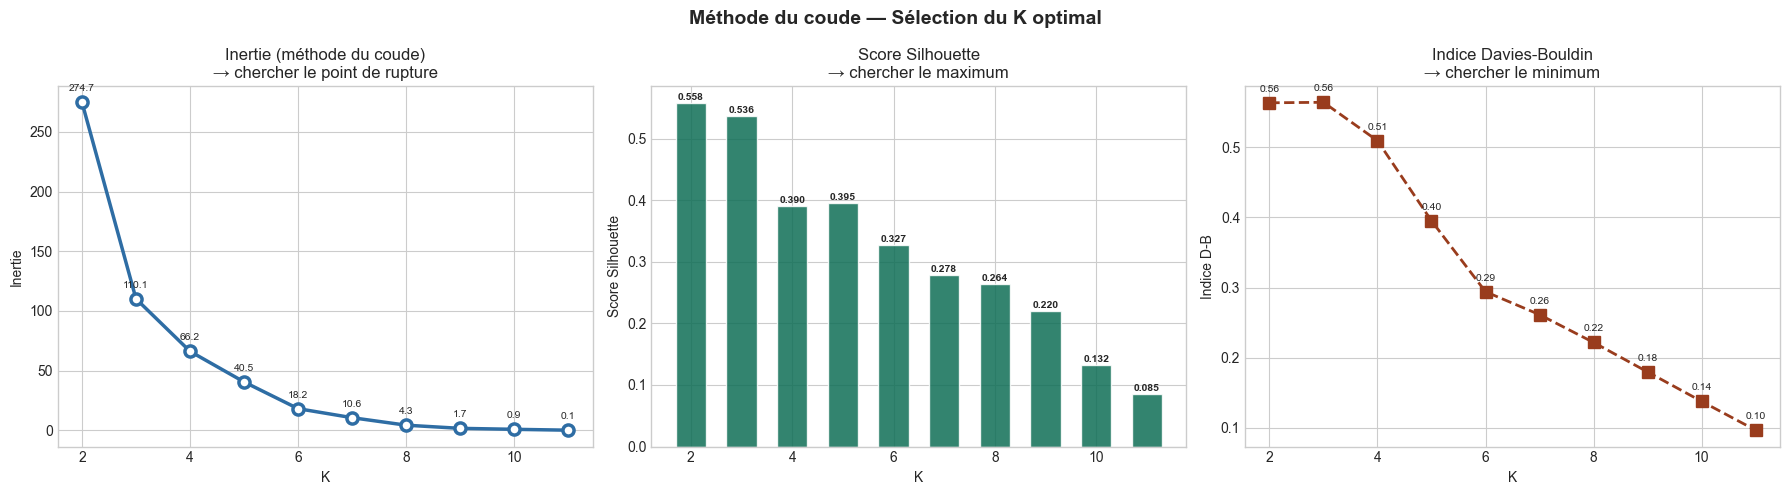


💡 Suggestions automatiques :
   Silhouette max   → K = 4  (score=0.5575)
   D-B min          → K = 11  (score=0.0963)
   C-H max          → K = 11  (score=418.2526)

✅ K optimal retenu : K = 4
   (Modifier K_OPT manuellement si la courbe du coude suggère autre chose)


In [41]:
# On passe tous les embeddings dans l'encodeur → espace latent Z (32 dims).
# On applique K-Means pour K = 2 à K_MAX et on trace 3 métriques.

from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,
                              davies_bouldin_score,
                              calinski_harabasz_score)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

PALETTE = ["#2e6da4", "#0f6e56", "#534ab7", "#ba7517", "#993c1d",
           "#3b6d11", "#a32d2d", "#5f5e5a", "#1a3a5c", "#d85a30"]
plt.style.use("seaborn-v0_8-whitegrid")

# ── Calcul de l'espace latent ─────────────────────────────────────────────────
ae.eval()
with torch.no_grad():
    _, Z = ae(X.to(device))
    Z_np = Z.cpu().numpy()   # (N, 32)

print(f"✅ Espace latent : {Z_np.shape}")

# ── Calcul des métriques pour chaque K ───────────────────────────────────────
# K_MAX = N-1 car K-Means ne peut pas avoir plus de clusters que de points
K_MAX  = min(12, len(df_projets) - 1)
K_MIN  = 2
k_vals = list(range(K_MIN, K_MAX + 1))

inerties, silhouettes, dbs, chs = [], [], [], []

print(f"\n{'K':>3} | {'Inertie':>10} | {'Silhouette':>10} | {'D-B':>8} | {'C-H':>10}")
print("-" * 50)

for k in k_vals:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    lbl = km.fit_predict(Z_np)

    iner = km.inertia_
    sil  = silhouette_score(Z_np, lbl)
    db   = davies_bouldin_score(Z_np, lbl)
    ch   = calinski_harabasz_score(Z_np, lbl)

    inerties.append(iner)
    silhouettes.append(sil)
    dbs.append(db)
    chs.append(ch)

    print(f"{k:>3} | {iner:>10.3f} | {sil:>10.4f} | {db:>8.4f} | {ch:>10.4f}")

# ── Visualisation des 3 critères ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Méthode du coude — Sélection du K optimal",
             fontsize=14, fontweight="bold")

# Graphique 1 : Inertie
axes[0].plot(k_vals, inerties, "o-",
             color=PALETTE[0], linewidth=2.5, markersize=8,
             markerfacecolor="white", markeredgewidth=2.5)
axes[0].set_title("Inertie (méthode du coude)\n→ chercher le point de rupture")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertie")
for k, v in zip(k_vals, inerties):
    axes[0].annotate(f"{v:.1f}", (k, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=7.5)

# Graphique 2 : Silhouette
axes[1].bar(k_vals, silhouettes,
            color=PALETTE[1], alpha=0.85, edgecolor="white", width=0.6)
axes[1].set_title("Score Silhouette\n→ chercher le maximum")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score Silhouette")
for k, v in zip(k_vals, silhouettes):
    axes[1].text(k, v + 0.005, f"{v:.3f}",
                 ha="center", fontsize=7.5, fontweight="bold")

# Graphique 3 : Davies-Bouldin
axes[2].plot(k_vals, dbs, "s--",
             color=PALETTE[4], linewidth=2, markersize=8)
axes[2].set_title("Indice Davies-Bouldin\n→ chercher le minimum")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Indice D-B")
for k, v in zip(k_vals, dbs):
    axes[2].annotate(f"{v:.2f}", (k, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=7.5)

plt.tight_layout()
plt.savefig("01_methode_coude.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Suggestion automatique ────────────────────────────────────────────────────
k_sil = k_vals[int(np.argmax(silhouettes))] +2
k_db  = k_vals[int(np.argmin(dbs))]
k_ch  = k_vals[int(np.argmax(chs))]

print(f"\n💡 Suggestions automatiques :")
print(f"   Silhouette max   → K = {k_sil}  (score={max(silhouettes):.4f})")
print(f"   D-B min          → K = {k_db}  (score={min(dbs):.4f})")
print(f"   C-H max          → K = {k_ch}  (score={max(chs):.4f})")

# ── K retenu ──────────────────────────────────────────────────────────────────
# On choisit le K le plus fréquent parmi les 3 critères.
# Modifier manuellement si la visualisation suggère un autre choix.
from collections import Counter
votes   = Counter([k_sil, k_db, k_ch])
K_OPT   = k_sil#votes.most_common(1)[0][0]
print(f"\n✅ K optimal retenu : K = {K_OPT}")
print("   (Modifier K_OPT manuellement si la courbe du coude suggère autre chose)")

In [43]:
K_OPT

4

Optimisation des hyper paramètres

In [ ]:
#!pip install optuna

🔍 Lancement de l'optimisation Optuna
   Méthode   : TPE (Tree-structured Parzen Estimator)
   Pruner    : MedianPruner
   Nb essais : 40
   Objectif  : maximiser le Score Silhouette
   K         : 4
------------------------------------------------------------


Best trial: 26. Best value: 0.875063: 100%|██████████| 40/40 [01:21<00:00,  2.03s/it]



MEILLEURS HYPERPARAMÈTRES TROUVÉS
  Score Silhouette optimal : 0.8751

  Hyperparamètres :
    dim_latente            = 16
    dropout                = 0.11484101472759686
    lr_pretrain            = 0.0025190969920898037
    lr_raffinement         = 0.0009884157497089987
    weight_decay           = 0.00021786442975076412
    gamma                  = 0.4075658092954163
    batch_size             = 16

  Essais complétés : 24
  Essais prunés    : 16


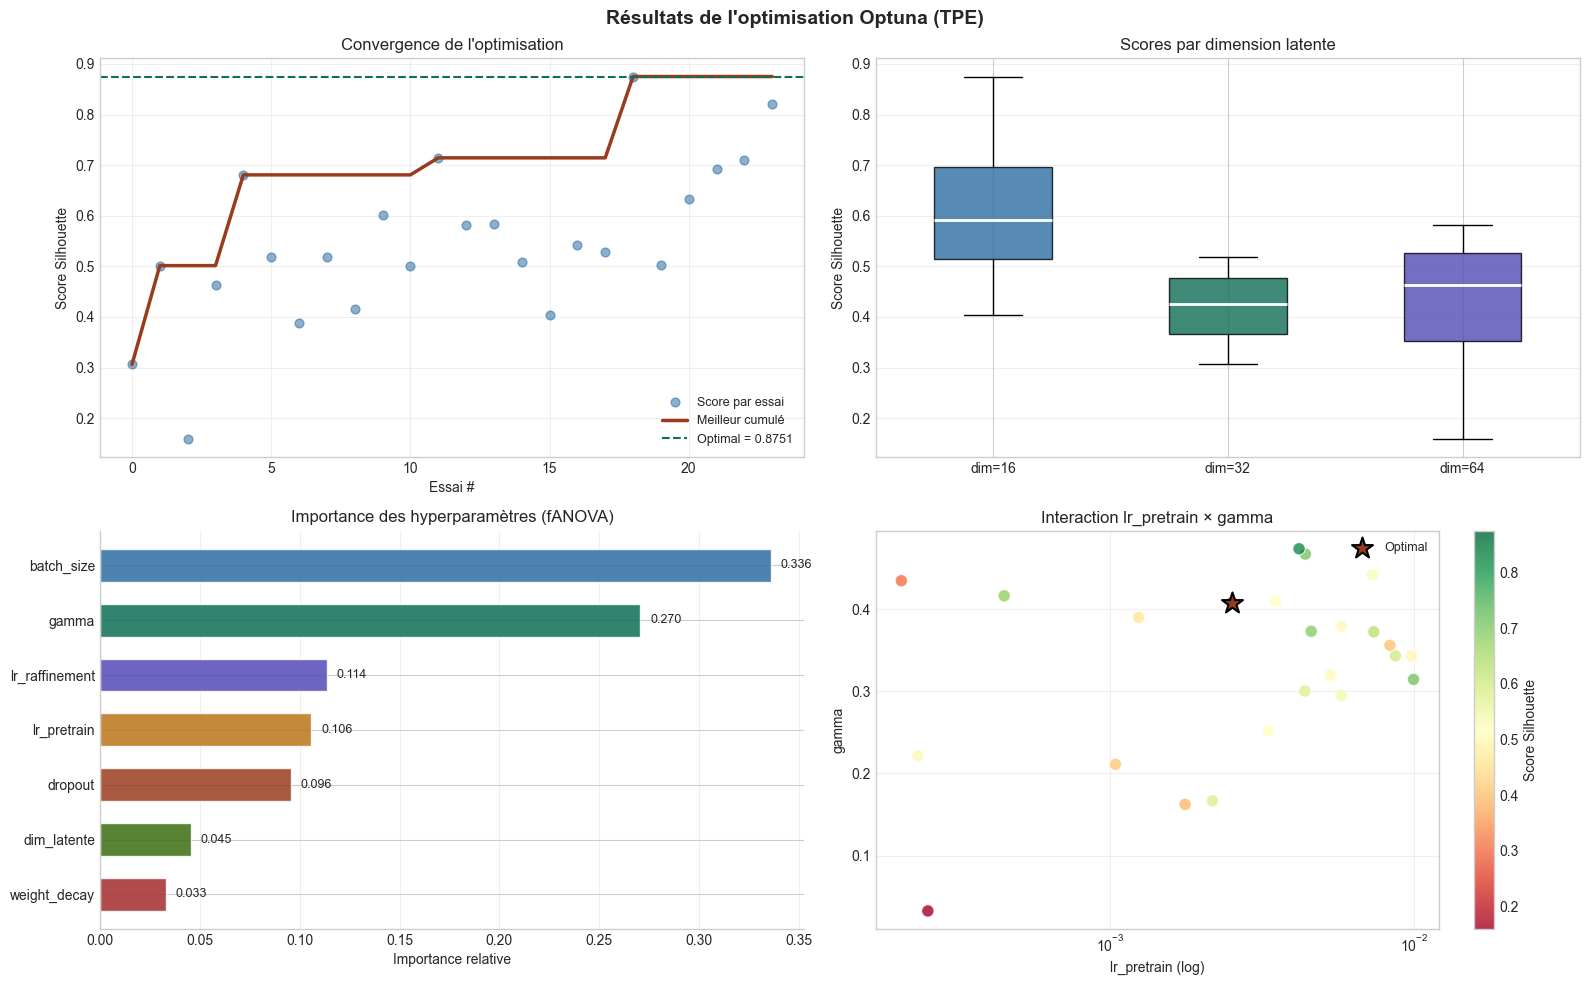


COMPARAISON HP INITIAUX vs OPTIMAUX
  Paramètre                   Initial       Optimal
--------------------------------------------------
  dim_latente                      32            16 ←
  dropout                        0.15  0.11484101472759686 ←
  lr_pretrain                   0.001  0.0025190969920898037 ←
  lr_raffinement               0.0001  0.0009884157497089987 ←
  weight_decay                 0.0001  0.00021786442975076412 ←
  gamma                           0.1  0.4075658092954163 ←
  batch_size                        4            16 ←

✅ HP mis à jour avec les valeurs optimales.
   Relancez maintenant la cellule 10 (pré-entraînement final).


In [44]:
# ==============================================================================
# CELLULE 9bis — OPTIMISATION DES HYPERPARAMÈTRES AVEC OPTUNA
# ==============================================================================

#!pip install optuna
import optuna
from optuna.trial import Trial
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS       = 40
EPOCHS_OPT_PRE = 100
EPOCHS_OPT_RAF = 80

# ── Définition des fonctions ici car cellule 10 n'est pas encore exécutée ─────
# Ces deux fonctions seront aussi réutilisées dans la cellule 10 (raffinement).

def soft_assignment(z: torch.Tensor,
                    mu: torch.Tensor,
                    alpha: float = 1.0) -> torch.Tensor:
    """
    Distribution Q : soft assignment par distribution T de Student.
    Q_ij = (1 + ||z_i - µ_j||² / alpha)^(-(alpha+1)/2) normalisé.
    """
    dist_sq = torch.sum(
        (z.unsqueeze(1) - mu.unsqueeze(0)) ** 2, dim=2
    )
    num = (1.0 + dist_sq / alpha) ** (-(alpha + 1.0) / 2.0)
    return num / num.sum(dim=1, keepdim=True)


def distribution_cible(Q: torch.Tensor) -> torch.Tensor:
    """
    Distribution P (cible) : version amplifiée de Q.
    P_ij = (Q_ij² / f_j) / Σ_j' (Q_ij'² / f_j')
    où f_j = Σ_i Q_ij
    """
    freq = Q.sum(dim=0, keepdim=True)
    P    = Q ** 2 / freq
    return P / P.sum(dim=1, keepdim=True)


# ==============================================================================
# FONCTION OBJECTIF
# ==============================================================================

def objectif(trial: Trial) -> float:
    """
    Entraîne un auto-encodeur + IDEC avec les HP proposés par Optuna
    et retourne le score Silhouette comme métrique de qualité.
    """

    # ── Proposition des HP ────────────────────────────────────────────────────
    dim_latente  = trial.suggest_categorical("dim_latente",  [16, 32, 64])
    dropout      = trial.suggest_float("dropout",            0.05, 0.40)
    lr_pretrain  = trial.suggest_float("lr_pretrain",        1e-4, 1e-2, log=True)
    lr_raf       = trial.suggest_float("lr_raffinement",     1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay",       1e-5, 1e-2, log=True)
    gamma        = trial.suggest_float("gamma",              0.01, 0.50)
    batch_size   = trial.suggest_categorical("batch_size",   [4, 8, 16])

    # Contrainte : lr_raffinement doit être < lr_pretrain
    if lr_raf >= lr_pretrain:
        raise optuna.exceptions.TrialPruned()

    # ── Construction du modèle ────────────────────────────────────────────────
    torch.manual_seed(SEED)
    ae_trial = AutoEncodeur(
        dim_entree  = 768,
        dim_latente = dim_latente,
        dropout     = dropout
    ).to(device)

    bs_eff = min(batch_size, len(X))
    loader_trial = DataLoader(
        TensorDataset(X),
        batch_size = bs_eff,
        shuffle    = True,
        drop_last  = False
    )
    mse_loss_trial = nn.MSELoss()

    # ── Pré-entraînement ──────────────────────────────────────────────────────
    opt_pre = optim.AdamW(ae_trial.parameters(),
                          lr=lr_pretrain,
                          weight_decay=weight_decay)
    sch_pre = optim.lr_scheduler.CosineAnnealingLR(
        opt_pre, T_max=EPOCHS_OPT_PRE, eta_min=1e-6
    )

    ae_trial.train()
    for epoch in range(EPOCHS_OPT_PRE):
        for (bx,) in loader_trial:
            bx = bx.to(device)
            x_rec, _ = ae_trial(bx)
            loss = mse_loss_trial(x_rec, bx)
            opt_pre.zero_grad()
            loss.backward()
            opt_pre.step()
        sch_pre.step()

        # Pruning : abandon si l'essai est non prometteur
        if epoch % 20 == 0:
            ae_trial.eval()
            with torch.no_grad():
                x_rec_all, _ = ae_trial(X.to(device))
                mse_val = mse_loss_trial(x_rec_all, X.to(device)).item()
            ae_trial.train()
            trial.report(-mse_val, step=epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    # ── Initialisation K-Means ────────────────────────────────────────────────
    ae_trial.eval()
    with torch.no_grad():
        _, Z_init = ae_trial(X.to(device))
        Z_np = Z_init.cpu().numpy()

    if dim_latente < K_OPT:
        raise optuna.exceptions.TrialPruned()

    km = KMeans(n_clusters=K_OPT, random_state=SEED,
                n_init=10, max_iter=300)
    km.fit(Z_np)

    centroides_trial = nn.Parameter(
        torch.tensor(km.cluster_centers_,
                     dtype=torch.float32).to(device)
    )

    # ── Raffinement IDEC ──────────────────────────────────────────────────────
    params_raf = list(ae_trial.parameters()) + [centroides_trial]
    opt_raf    = optim.AdamW(params_raf,
                              lr=lr_raf,
                              weight_decay=weight_decay)

    ae_trial.train()
    for epoch in range(EPOCHS_OPT_RAF):
        for (bx,) in loader_trial:
            bx       = bx.to(device)
            x_rec, z = ae_trial(bx)
            L_mse    = mse_loss_trial(x_rec, bx)
            Q_b      = soft_assignment(z, centroides_trial)
            P_b      = distribution_cible(Q_b).detach()
            eps      = 1e-10
            L_kl     = (P_b * torch.log(
                            (P_b + eps) / (Q_b + eps)
                        )).sum(dim=1).mean()
            L        = L_mse + gamma * L_kl
            opt_raf.zero_grad()
            L.backward()
            opt_raf.step()

    # ── Score Silhouette final ────────────────────────────────────────────────
    ae_trial.eval()
    with torch.no_grad():
        _, Z_fin = ae_trial(X.to(device))
        Z_fin_np = Z_fin.cpu().numpy()
        Q_fin    = soft_assignment(Z_fin, centroides_trial)
        labels   = Q_fin.cpu().numpy().argmax(axis=1)

    if len(np.unique(labels)) < K_OPT:
        return -1.0

    return silhouette_score(Z_fin_np, labels)


# ==============================================================================
# LANCEMENT
# ==============================================================================

sampler = optuna.samplers.TPESampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner(
    n_startup_trials = 5,
    n_warmup_steps   = 20,
    interval_steps   = 10
)
study = optuna.create_study(
    direction  = "maximize",
    sampler    = sampler,
    pruner     = pruner,
    study_name = "deep_clustering_magnus"
)

print(f"🔍 Lancement de l'optimisation Optuna")
print(f"   Méthode   : TPE (Tree-structured Parzen Estimator)")
print(f"   Pruner    : MedianPruner")
print(f"   Nb essais : {N_TRIALS}")
print(f"   Objectif  : maximiser le Score Silhouette")
print(f"   K         : {K_OPT}")
print("-" * 60)

study.optimize(objectif, n_trials=N_TRIALS, show_progress_bar=True)

# ==============================================================================
# RÉSULTATS
# ==============================================================================

meilleur = study.best_trial

print("\n" + "=" * 60)
print("MEILLEURS HYPERPARAMÈTRES TROUVÉS")
print("=" * 60)
print(f"  Score Silhouette optimal : {meilleur.value:.4f}")
print(f"\n  Hyperparamètres :")
for k, v in meilleur.params.items():
    print(f"    {k:<22} = {v}")

n_pruned   = len([t for t in study.trials
                  if t.state == optuna.trial.TrialState.PRUNED])
n_complete = len([t for t in study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE])
print(f"\n  Essais complétés : {n_complete}")
print(f"  Essais prunés    : {n_pruned}")

# ==============================================================================
# VISUALISATION
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Résultats de l'optimisation Optuna (TPE)",
             fontsize=14, fontweight="bold")

# Graphique 1 : convergence
scores_complets = [
    t.value for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE
]
meilleur_courant = [max(scores_complets[:i+1])
                    for i in range(len(scores_complets))]

axes[0, 0].scatter(range(len(scores_complets)), scores_complets,
                   color=PALETTE[0], alpha=0.55, s=40, label="Score par essai")
axes[0, 0].plot(range(len(scores_complets)), meilleur_courant,
                color=PALETTE[4], linewidth=2.5, label="Meilleur cumulé")
axes[0, 0].axhline(meilleur.value, color=PALETTE[1],
                   linewidth=1.5, linestyle="--",
                   label=f"Optimal = {meilleur.value:.4f}")
axes[0, 0].set_xlabel("Essai #")
axes[0, 0].set_ylabel("Score Silhouette")
axes[0, 0].set_title("Convergence de l'optimisation")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Graphique 2 : boxplot par dim_latente
dims_tried = {}
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        d = t.params.get("dim_latente")
        dims_tried.setdefault(d, []).append(t.value)

dims_sorted = sorted(dims_tried.keys())
bp = axes[0, 1].boxplot(
    [dims_tried[d] for d in dims_sorted],
    patch_artist=True, widths=0.5,
    medianprops={"color": "white", "linewidth": 2}
)
for patch, c in zip(bp["boxes"],
                    [PALETTE[i] for i in range(len(dims_sorted))]):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
axes[0, 1].set_xticks(range(1, len(dims_sorted)+1))
axes[0, 1].set_xticklabels([f"dim={d}" for d in dims_sorted])
axes[0, 1].set_ylabel("Score Silhouette")
axes[0, 1].set_title("Scores par dimension latente")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Graphique 3 : importance des HP
try:
    importances = optuna.importance.get_param_importances(study)
    bars_imp = axes[1, 0].barh(
        list(importances.keys()), list(importances.values()),
        color=[PALETTE[i % len(PALETTE)]
               for i in range(len(importances))],
        alpha=0.85, edgecolor="white", height=0.6
    )
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlabel("Importance relative")
    axes[1, 0].set_title("Importance des hyperparamètres (fANOVA)")
    axes[1, 0].grid(True, alpha=0.3, axis="x")
    axes[1, 0].spines["top"].set_visible(False)
    axes[1, 0].spines["right"].set_visible(False)
    for b, v in zip(bars_imp, importances.values()):
        axes[1, 0].text(b.get_width() + 0.005,
                        b.get_y() + b.get_height()/2,
                        f"{v:.3f}", va="center", fontsize=9)
except Exception:
    axes[1, 0].text(0.5, 0.5,
                    "Importance non disponible\n(pas assez d'essais)",
                    ha="center", va="center",
                    transform=axes[1, 0].transAxes)
    axes[1, 0].axis("off")

# Graphique 4 : lr_pretrain vs gamma
lrs_p, gams_p, scs_p = [], [], []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        lrs_p.append(t.params.get("lr_pretrain", np.nan))
        gams_p.append(t.params.get("gamma", np.nan))
        scs_p.append(t.value)

sc = axes[1, 1].scatter(lrs_p, gams_p, c=scs_p,
                         cmap="RdYlGn", s=80, alpha=0.8,
                         edgecolors="white", linewidth=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Score Silhouette")
axes[1, 1].scatter(meilleur.params["lr_pretrain"],
                   meilleur.params["gamma"],
                   s=250, marker="*", color=PALETTE[4],
                   edgecolors="black", linewidth=1.5,
                   zorder=5, label="Optimal")
axes[1, 1].set_xlabel("lr_pretrain (log)")
axes[1, 1].set_ylabel("gamma")
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Interaction lr_pretrain × gamma")
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("14_optuna_resultats.png", dpi=150, bbox_inches="tight")
plt.show()

# ==============================================================================
# MISE À JOUR DE HP
# ==============================================================================

HP_INITIAL = {
    "dim_latente": 32,    "dropout"       : 0.15,
    "lr_pretrain": 1e-3,  "lr_raffinement": 1e-4,
    "weight_decay": 1e-4, "gamma"         : 0.1,
    "batch_size"  : 4,
}

HP = {
    "dim_latente"        : meilleur.params["dim_latente"],
    "dropout"            : meilleur.params["dropout"],
    "lr_pretrain"        : meilleur.params["lr_pretrain"],
    "lr_raffinement"     : meilleur.params["lr_raffinement"],
    "weight_decay"       : meilleur.params["weight_decay"],
    "gamma"              : meilleur.params["gamma"],
    "batch_size"         : meilleur.params["batch_size"],
    "epochs_pretrain"    : 300,
    "epochs_raffinement" : 200,
    "T_update"           : 10,
    "alpha_student"      : 1.0,
}

print("\n" + "=" * 60)
print("COMPARAISON HP INITIAUX vs OPTIMAUX")
print("=" * 60)
print(f"  {'Paramètre':<22} {'Initial':>12}  {'Optimal':>12}")
print("-" * 50)
for k in HP_INITIAL:
    flag = " ←" if HP_INITIAL[k] != HP[k] else ""
    print(f"  {k:<22} {str(HP_INITIAL[k]):>12}  {str(HP[k]):>12}{flag}")

print("\n✅ HP mis à jour avec les valeurs optimales.")
print("   Relancez maintenant la cellule 10 (pré-entraînement final).")

# ==============================================================================
# CELLULE 10 — RAFFINEMENT IDEC (IMPROVED DEEP EMBEDDED CLUSTERING)
# ==============================================================================


In [45]:
# Phase 2 : optimisation conjointe encodeur + clusters.
# Perte totale : L = L_MSE + gamma * L_KL
# L_KL = divergence de Kullback-Leibler entre P (cible) et Q (soft assignment)

# ── Initialisation des centroïdes par K-Means ─────────────────────────────────
ae.eval()
with torch.no_grad():
    _, Z_init = ae(X.to(device))
    Z_init_np = Z_init.cpu().numpy()

km_init  = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=20, max_iter=500)
km_init.fit(Z_init_np)

# Les centroïdes sont des paramètres appris, initialisés par K-Means
centroides = nn.Parameter(
    torch.tensor(km_init.cluster_centers_,
                 dtype=torch.float32).to(device)
)
print(f"✅ Centroïdes initialisés | shape = {centroides.shape}")


def soft_assignment(z: torch.Tensor,
                    mu: torch.Tensor,
                    alpha: float = 1.0) -> torch.Tensor:
    """
    Distribution Q : soft assignment par distribution T de Student.

    Q_ij = (1 + ||z_i - µ_j||² / alpha)^(-(alpha+1)/2)
           ──────────────────────────────────────────────
           Σ_j' même expression

    Plus z_i est proche de µ_j, plus Q_ij est élevé.
    """
    # dist_sq[i, j] = ||z_i - µ_j||²
    dist_sq = torch.sum(
        (z.unsqueeze(1) - mu.unsqueeze(0)) ** 2, dim=2
    )  # (N, K)

    num = (1.0 + dist_sq / alpha) ** (-(alpha + 1.0) / 2.0)
    return num / num.sum(dim=1, keepdim=True)   # (N, K)


def distribution_cible(Q: torch.Tensor) -> torch.Tensor:
    """
    Distribution P (cible) : version amplifiée de Q.

    P_ij = (Q_ij² / f_j) / Σ_j' (Q_ij'² / f_j')
    où f_j = Σ_i Q_ij  (fréquence du cluster j)

    P est plus "piquée" que Q : les assignations confiantes
    sont renforcées, les ambiguës sont atténuées.
    """
    freq = Q.sum(dim=0, keepdim=True)   # (1, K)
    P    = Q ** 2 / freq
    return P / P.sum(dim=1, keepdim=True)   # (N, K)


# ── Optimiseur pour le raffinement ────────────────────────────────────────────
# On optimise les poids du réseau ET les centroïdes ensemble
params_raf  = list(ae.parameters()) + [centroides]
optim_raf   = optim.AdamW(
    params_raf,
    lr           = HP["lr_raffinement"],
    weight_decay = HP["weight_decay"]
)

hist_total  = []   # Perte totale L = L_MSE + gamma*L_KL
hist_mse    = []   # Perte reconstruction seule
hist_kl     = []   # Perte clustering seule

print("⏳ Raffinement IDEC en cours...\n")
print(f"{'Epoch':>6} | {'L_total':>10} | {'L_MSE':>10} | {'L_KL':>10}")
print("-" * 45)

for epoch in range(1, HP["epochs_raffinement"] + 1):
    ae.train()
    ep_total = ep_mse = ep_kl = 0.0

    for (bx,) in loader:
        bx = bx.to(device)
        x_rec, z = ae(bx)

        # ── Perte de reconstruction ───────────────────────────────────────────
        L_mse = mse_loss(x_rec, bx)

        # ── Soft assignment Q pour ce batch ───────────────────────────────────
        Q_batch = soft_assignment(z, centroides, HP["alpha_student"])

        # ── Distribution cible P (détachée : pas de gradient sur P) ──────────
        P_batch = distribution_cible(Q_batch).detach()

        # ── Divergence KL(P || Q) ─────────────────────────────────────────────
        eps   = 1e-10
        L_kl  = (P_batch * torch.log(
                    (P_batch + eps) / (Q_batch + eps)
                 )).sum(dim=1).mean()

        # ── Perte totale IDEC ─────────────────────────────────────────────────
        L = L_mse + HP["gamma"] * L_kl

        optim_raf.zero_grad()
        L.backward()
        optim_raf.step()

        n = len(bx)
        ep_total += L.item()     * n
        ep_mse   += L_mse.item() * n
        ep_kl    += L_kl.item()  * n

    N = len(X)
    hist_total.append(ep_total / N)
    hist_mse.append(ep_mse   / N)
    hist_kl.append(ep_kl    / N)

    if epoch % 40 == 0 or epoch == 1:
        print(f"{epoch:>6} | {hist_total[-1]:>10.6f}"
              f" | {hist_mse[-1]:>10.6f}"
              f" | {hist_kl[-1]:>10.6f}")

print(f"\n✅ Raffinement terminé"
      f" | L_total initiale={hist_total[0]:.6f}"
      f" | L_total finale={hist_total[-1]:.6f}")

✅ Centroïdes initialisés | shape = torch.Size([4, 32])
⏳ Raffinement IDEC en cours...

 Epoch |    L_total |      L_MSE |       L_KL
---------------------------------------------
     1 |   0.050277 |   0.000754 |   0.121508
    40 |   0.026533 |   0.000233 |   0.064529
    80 |   0.020224 |   0.000174 |   0.049195
   120 |   0.024862 |   0.000170 |   0.060584
   160 |   0.031947 |   0.000145 |   0.078029
   200 |   0.020864 |   0.000127 |   0.050882

✅ Raffinement terminé | L_total initiale=0.050277 | L_total finale=0.020864


# ==============================================================================
# CELLULE 11 — VISUALISATION DES FONCTIONS DE PERTE
# ==============================================================================


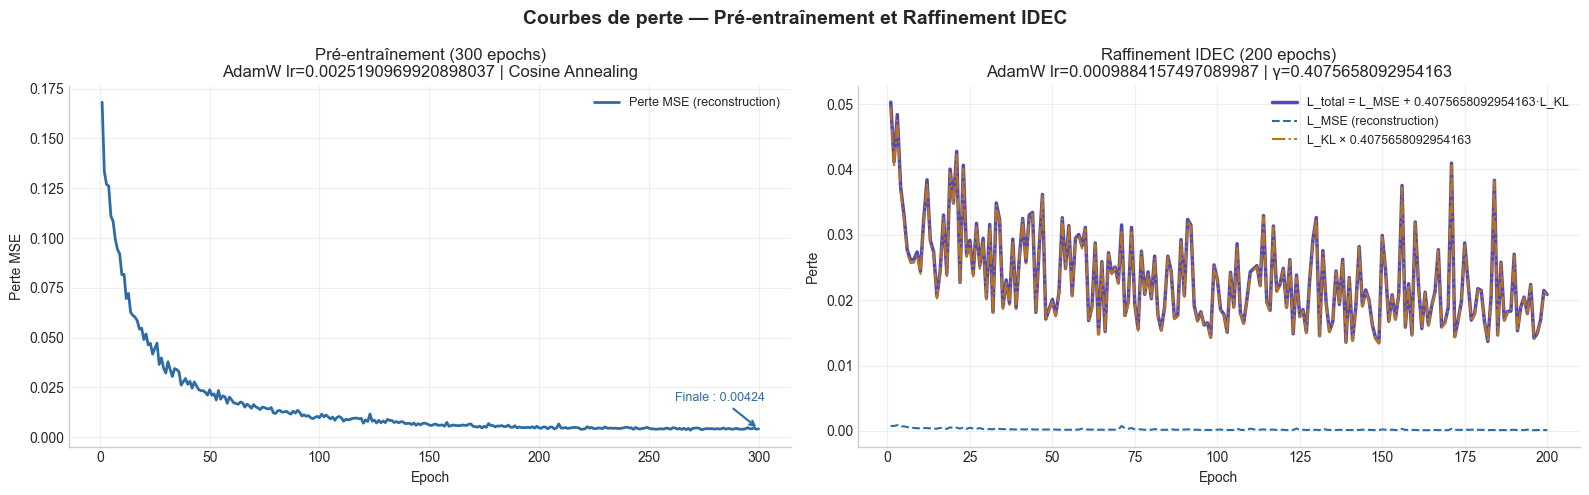

✅ Graphique sauvegardé : 02_courbes_perte.png

📊 Interprétation :
   Pré-entraînement : réduction de la perte MSE de 97.5%
   Raffinement IDEC : réduction de la perte totale de 58.5%
   ✅ L_KL décroissante → les clusters se resserrent correctement.


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Courbes de perte — Pré-entraînement et Raffinement IDEC",
             fontsize=14, fontweight="bold")

# ── Graphique 1 : Pré-entraînement ───────────────────────────────────────────
ep_pre = range(1, len(hist_pre) + 1)
axes[0].plot(ep_pre, hist_pre, color=PALETTE[0], linewidth=2,
             label="Perte MSE (reconstruction)")
axes[0].set_title(f"Pré-entraînement ({HP['epochs_pretrain']} epochs)\n"
                  f"AdamW lr={HP['lr_pretrain']} | Cosine Annealing")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Perte MSE")
axes[0].legend(fontsize=9)

# Annotation de la valeur finale
axes[0].annotate(
    f"Finale : {hist_pre[-1]:.5f}",
    xy=(len(hist_pre), hist_pre[-1]),
    xytext=(-60, 20), textcoords="offset points",
    fontsize=9, color=PALETTE[0],
    arrowprops=dict(arrowstyle="->", color=PALETTE[0], lw=1.5)
)

# ── Graphique 2 : Raffinement IDEC ───────────────────────────────────────────
ep_raf = range(1, len(hist_total) + 1)
axes[1].plot(ep_raf, hist_total, color=PALETTE[2], linewidth=2.5,
             label=f"L_total = L_MSE + {HP['gamma']}·L_KL")
axes[1].plot(ep_raf, hist_mse, color=PALETTE[0], linewidth=1.5,
             linestyle="--", label="L_MSE (reconstruction)")
axes[1].plot(ep_raf, [v * HP["gamma"] for v in hist_kl],
             color=PALETTE[3], linewidth=1.5,
             linestyle="-.", label=f"L_KL × {HP['gamma']}")

axes[1].set_title(f"Raffinement IDEC ({HP['epochs_raffinement']} epochs)\n"
                  f"AdamW lr={HP['lr_raffinement']} | γ={HP['gamma']}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perte")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("02_courbes_perte.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 02_courbes_perte.png")

# ── Commentaires automatiques ─────────────────────────────────────────────────
print("\n📊 Interprétation :")
red_pre = (1 - hist_pre[-1] / hist_pre[0]) * 100
red_raf = (1 - hist_total[-1] / hist_total[0]) * 100
print(f"   Pré-entraînement : réduction de la perte MSE de {red_pre:.1f}%")
print(f"   Raffinement IDEC : réduction de la perte totale de {red_raf:.1f}%")
if hist_kl[-1] < hist_kl[0]:
    print("   ✅ L_KL décroissante → les clusters se resserrent correctement.")
else:
    print("   ⚠ L_KL instable → envisager de réduire gamma.")

# ==============================================================================
# CELLULE 12 — ASSIGNATION FINALE DES CLUSTERS ET MÉTRIQUES DE QUALITÉ
# ==============================================================================


In [48]:
ae.eval()
with torch.no_grad():
    _, Z_fin   = ae(X.to(device))
    Z_fin_np   = Z_fin.cpu().numpy()
    Q_fin      = soft_assignment(Z_fin, centroides, HP["alpha_student"])
    Q_fin_np   = Q_fin.cpu().numpy()

# Label = cluster ayant la probabilité Q la plus élevée
labels = Q_fin_np.argmax(axis=1)

# Ajout dans df_projets
df_projets["CLUSTER"]    = labels
df_projets["CONFIANCE"]  = Q_fin_np.max(axis=1)   # Probabilité max

# ── Métriques de qualité ──────────────────────────────────────────────────────
sil = silhouette_score(Z_fin_np, labels)
db  = davies_bouldin_score(Z_fin_np, labels)
ch  = calinski_harabasz_score(Z_fin_np, labels)

print("=" * 55)
print(f"MÉTRIQUES FINALES — K = {K_OPT}")
print("=" * 55)
print(f"  Score Silhouette        : {sil:.4f}")
print(f"  Davies-Bouldin Index    : {db:.4f}")
print(f"  Calinski-Harabasz Score : {ch:.4f}")
print()

# Interprétations automatiques
print("INTERPRÉTATIONS :")
if sil > 0.50:
    msg_sil = "✅ Excellent (> 0.50) — clusters bien séparés et cohésifs"
elif sil > 0.25:
    msg_sil = "✅ Acceptable (0.25–0.50) — structure raisonnable"
else:
    msg_sil = "⚠ Faible (< 0.25) — clusters peu distincts, essayer un autre K"
print(f"  Silhouette  : {msg_sil}")

if db < 1.0:
    msg_db = "✅ Excellent (< 1.0)"
elif db < 1.5:
    msg_db = "✅ Bon (1.0–1.5)"
else:
    msg_db = "⚠ Moyen (> 1.5) — clusters trop proches ou dispersés"
print(f"  D-B Index   : {msg_db}")
print(f"  C-H Score   : plus la valeur est grande, meilleur est le clustering.")

# ── Contenu des clusters ──────────────────────────────────────────────────────
print("\nCOMPOSITION DES CLUSTERS :")
print("-" * 55)
for c in sorted(df_projets["CLUSTER"].unique()):
    grp      = df_projets[df_projets["CLUSTER"] == c]
    conf_moy = grp["CONFIANCE"].mean()
    print(f"\n  Cluster {c}  ({len(grp)} projet(s) | "
          f"confiance moy. = {conf_moy:.3f})")
    for _, r in grp.iterrows():
        print(f"    [{r['ID_PROJET']}]  {r['INTITULE_PROJET'][:65]}")

MÉTRIQUES FINALES — K = 4
  Score Silhouette        : 0.4483
  Davies-Bouldin Index    : 0.4905
  Calinski-Harabasz Score : 15.6751

INTERPRÉTATIONS :
  Silhouette  : ✅ Acceptable (0.25–0.50) — structure raisonnable
  D-B Index   : ✅ Excellent (< 1.0)
  C-H Score   : plus la valeur est grande, meilleur est le clustering.

COMPOSITION DES CLUSTERS :
-------------------------------------------------------

  Cluster 0  (2 projet(s) | confiance moy. = 0.851)
    [54A009P00018]  Mise en place d’un Système de Sécurité Incendie à l’Unité Spécial
    [54A009P00015]  Mise en place d’un Système de Vidéosurveillance à l’Unité Spécial

  Cluster 1  (2 projet(s) | confiance moy. = 0.774)
    [54A009P00008]  Acquisition des matériels roulants pour les services de la Cour P
    [54A009P00005]  Acquisition du matériel informatique

  Cluster 2  (2 projet(s) | confiance moy. = 0.706)
    [54A009P00002]  Mise en place d’une application hypermoderne
    [54A009P00020]  Mise en place d’une Bibliothèque M

# ==============================================================================
# CELLULE 13 — VISUALISATION DES CLUSTERS (t-SNE / UMAP)
# ==============================================================================


✅ Projection UMAP : (12, 2)


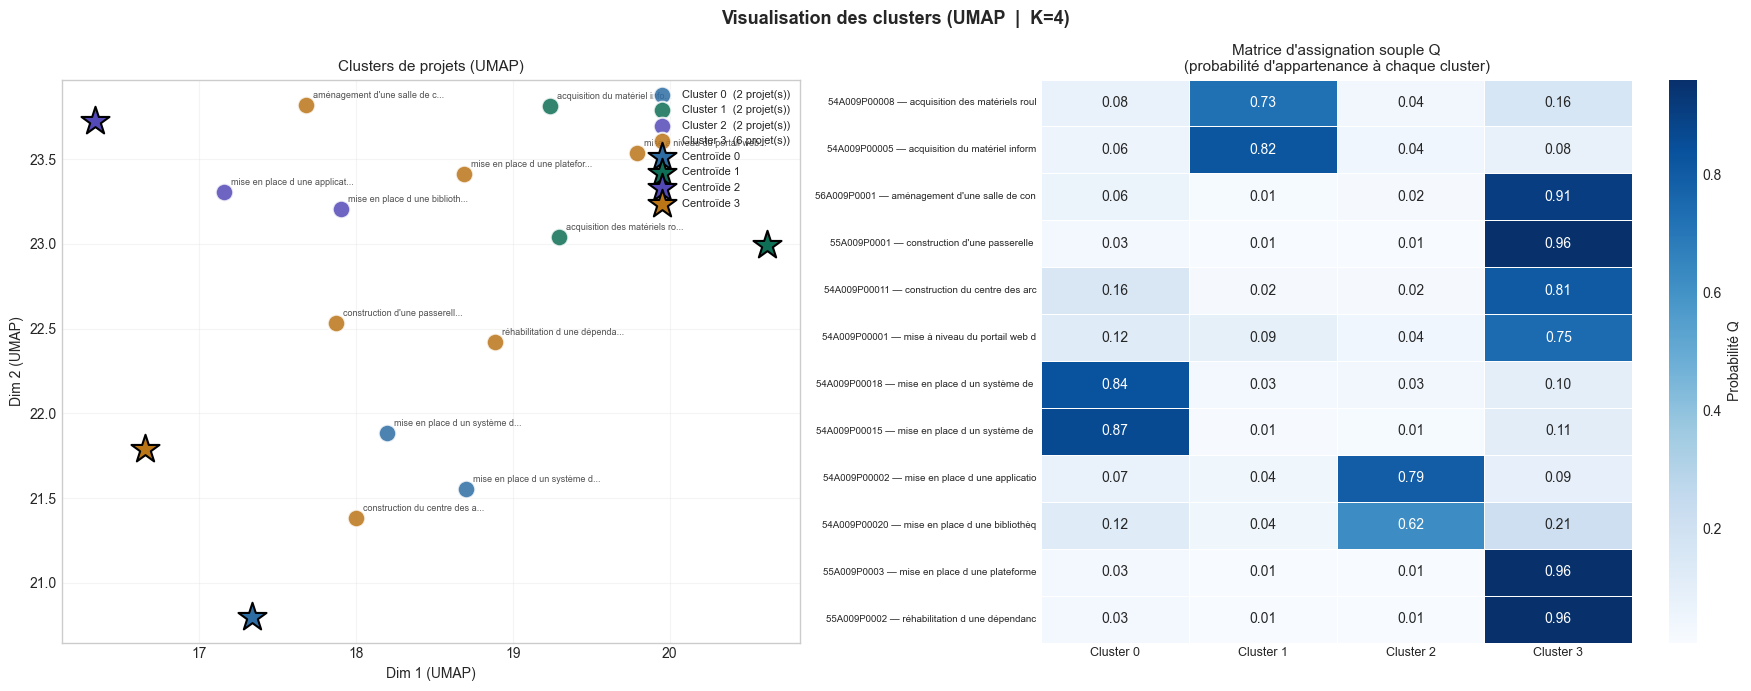

✅ Graphique sauvegardé : 03_clusters.png


In [49]:
from sklearn.decomposition import PCA

# ── Projection 2D ────────────────────────────────────────────────────────────
# On essaie UMAP (plus fidèle), on replie sur PCA si non disponible.
try:
    import umap
    reducer      = umap.UMAP(n_components=2, random_state=SEED,
                              n_neighbors=min(5, len(df_projets)-1),
                              min_dist=0.1)
    Z_2d         = reducer.fit_transform(Z_fin_np)
    methode      = "UMAP"
    centroides_2d = reducer.transform(centroides.detach().cpu().numpy())
except Exception:
    pca          = PCA(n_components=2, random_state=SEED)
    Z_2d         = pca.fit_transform(Z_fin_np)
    methode      = "PCA"
    centroides_2d = pca.transform(centroides.detach().cpu().numpy())

print(f"✅ Projection {methode} : {Z_2d.shape}")

# ── Couleurs par cluster ──────────────────────────────────────────────────────
coul = [PALETTE[i % len(PALETTE)] for i in range(K_OPT)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f"Visualisation des clusters ({methode}  |  K={K_OPT})",
             fontsize=13, fontweight="bold")

# ── Graphique 1 : scatter + centroïdes ───────────────────────────────────────
for c in range(K_OPT):
    msk = labels == c
    axes[0].scatter(Z_2d[msk, 0], Z_2d[msk, 1],
                    c=coul[c], s=160, alpha=0.85,
                    edgecolors="white", linewidth=1.5,
                    label=f"Cluster {c}  ({msk.sum()} projet(s))",
                    zorder=3)

# Labels des projets
for i in range(len(df_projets)):
    etiquette = (df_projets.iloc[i]["INTITULE_CLEAN"][:28] + "..."
                 if len(df_projets.iloc[i]["INTITULE_CLEAN"]) > 28
                 else df_projets.iloc[i]["INTITULE_CLEAN"])
    axes[0].annotate(etiquette, xy=(Z_2d[i, 0], Z_2d[i, 1]),
                     xytext=(5, 5), textcoords="offset points",
                     fontsize=6.5, alpha=0.8)

# Centroïdes
for c in range(K_OPT):
    axes[0].scatter(centroides_2d[c, 0], centroides_2d[c, 1],
                    c=coul[c], s=450, marker="*",
                    edgecolors="black", linewidth=1.5,
                    zorder=5, label=f"Centroïde {c}")

axes[0].set_title(f"Clusters de projets ({methode})", fontsize=11)
axes[0].set_xlabel(f"Dim 1 ({methode})")
axes[0].set_ylabel(f"Dim 2 ({methode})")
axes[0].legend(loc="best", fontsize=8, framealpha=0.85)
axes[0].grid(True, alpha=0.2)

# ── Graphique 2 : heatmap des probabilités Q ─────────────────────────────────
labels_lignes = [
    (r["ID_PROJET"] + " — " + r["INTITULE_CLEAN"][:30])
    for _, r in df_projets.iterrows()
]
Q_df = pd.DataFrame(
    Q_fin_np,
    index   = labels_lignes,
    columns = [f"Cluster {c}" for c in range(K_OPT)]
)

sns.heatmap(Q_df, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Probabilité Q"},
            ax=axes[1])
axes[1].set_title("Matrice d'assignation souple Q\n"
                  "(probabilité d'appartenance à chaque cluster)",
                  fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=7, rotation=0)

plt.tight_layout()
plt.savefig("03_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 03_clusters.png")

Nommage des clusters

NOMMAGE DES CLUSTERS PAR TF-IDF

  Cluster 0  →  Un système · Place un · Système
  Mots-clés : ['un système', 'place un', 'système']
    • Mise en place d’un Système de Sécurité Incendie à l’Unité Spécial
    • Mise en place d’un Système de Vidéosurveillance à l’Unité Spécial

  Cluster 1  →  Acquisition · Services de · Matériels roulants
  Mots-clés : ['acquisition', 'services de', 'matériels roulants']
    • Acquisition des matériels roulants pour les services de la Cour P
    • Acquisition du matériel informatique

  Cluster 2  →  Place une · Une · Mise
  Mots-clés : ['place une', 'une', 'mise']
    • Mise en place d’une application hypermoderne
    • Mise en place d’une Bibliothèque Multimédia

  Cluster 3  →  De · Une · Cour
  Mots-clés : ['de', 'une', 'cour']
    • Aménagement d'une salle de conférence moderne pour visioconférenc
    • Construction d'une passerelle et sécurisation des bâtiments de la
    • Construction du Centre des Archives de l’Unité Spéciale
    • Mise à nivea

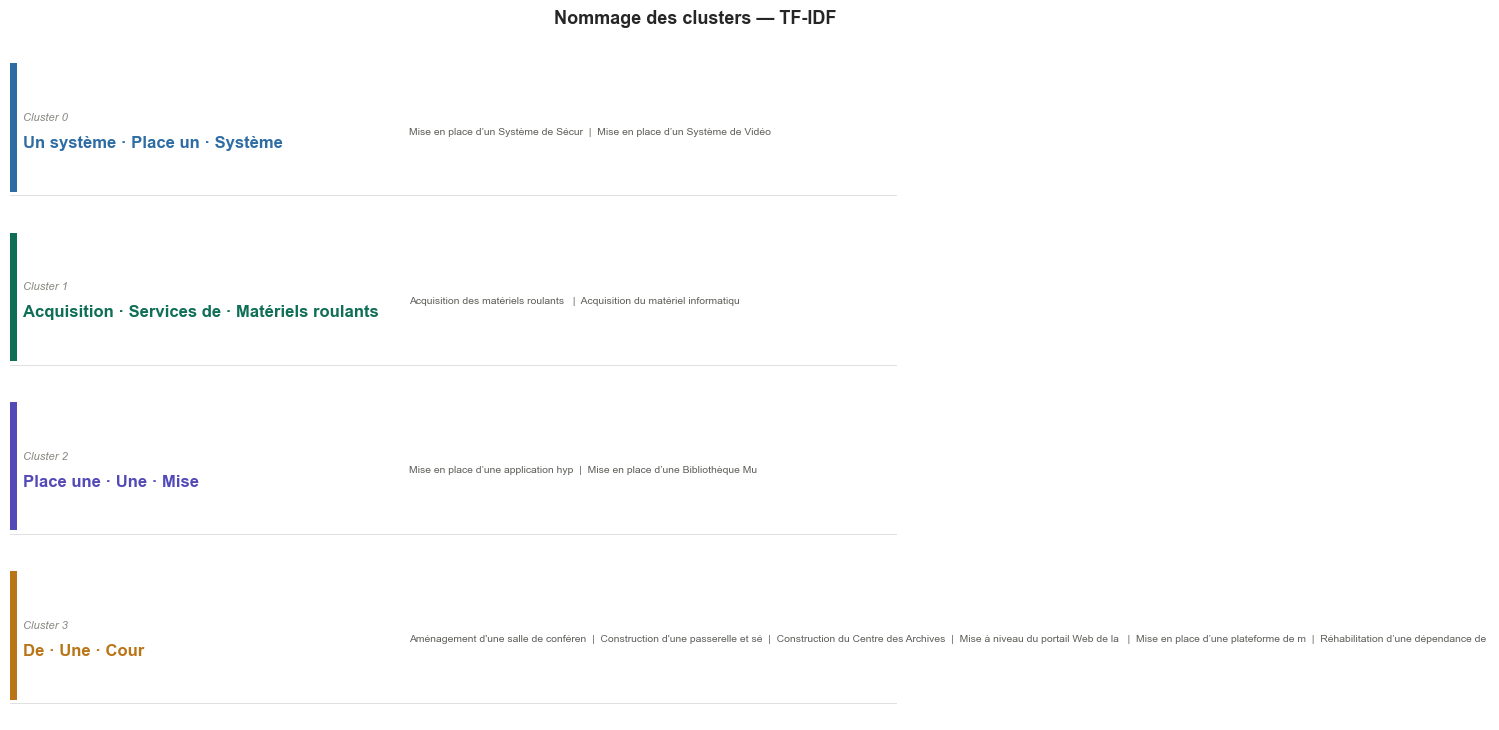

✅ Graphique sauvegardé : 15_noms_clusters_tfidf.png


In [50]:
# ==============================================================================
# NOMMAGE DES CLUSTERS PAR TF-IDF (sans API, 100% local)
# ==============================================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# ── Corpus : un document par cluster ─────────────────────────────────────────
ids_clusters = sorted(df_projets["CLUSTER"].unique().astype(int))

corpus = {
    c: " ".join(df_projets[df_projets["CLUSTER"] == c]["INTITULE_CLEAN"].tolist())
    for c in ids_clusters
}

# ── Vectorisation TF-IDF ──────────────────────────────────────────────────────
vectorizer    = TfidfVectorizer(min_df=1, max_df=0.9, ngram_range=(1, 2))
matrice_tfidf = vectorizer.fit_transform(list(corpus.values()))
vocabulaire   = vectorizer.get_feature_names_out()

# ── Extraction des mots-clés et nommage ───────────────────────────────────────
N_MOTS        = 3
noms_clusters = {}

print("=" * 60)
print("NOMMAGE DES CLUSTERS PAR TF-IDF")
print("=" * 60)

for i, c_id in enumerate(ids_clusters):
    scores    = matrice_tfidf[i].toarray().flatten()
    top_idx   = scores.argsort()[::-1][:N_MOTS]
    mots_cles = [vocabulaire[j] for j in top_idx if scores[j] > 0]
    nom       = " · ".join([m.capitalize() for m in mots_cles]) \
                if mots_cles else f"Cluster {c_id}"

    intitules = df_projets[df_projets["CLUSTER"] == c_id]["INTITULE_PROJET"].tolist()

    noms_clusters[c_id] = {
        "cluster"  : c_id,
        "nom"      : nom,
        "mots_cles": mots_cles,
        "intitules": intitules
    }

    print(f"\n  Cluster {c_id}  →  {nom}")
    print(f"  Mots-clés : {mots_cles}")
    for titre in intitules:
        print(f"    • {titre[:65]}")

# ── Intégration dans df_projets uniquement ────────────────────────────────────
df_projets["NOM_CLUSTER"] = df_projets["CLUSTER"].apply(
    lambda c: noms_clusters[int(c)]["nom"]
)

print("\n✅ Colonne NOM_CLUSTER ajoutée dans df_projets")
print(df_projets[["ID_PROJET", "INTITULE_PROJET",
                   "CLUSTER", "NOM_CLUSTER"]].to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, len(noms_clusters) * 1.6 + 1))
fig.suptitle("Nommage des clusters — TF-IDF", fontsize=13, fontweight="bold")
ax.axis("off")

for i, (c_id, res) in enumerate(noms_clusters.items()):
    y    = 1 - (i + 0.5) / len(noms_clusters)
    coul = PALETTE[c_id % len(PALETTE)]

    ax.add_patch(plt.Rectangle(
        (0, y - 0.38 / len(noms_clusters)), 0.008,
        0.76 / len(noms_clusters),
        transform=ax.transAxes,
        facecolor=coul, clip_on=False
    ))
    ax.text(0.015, y + 0.01, f"Cluster {c_id}",
            transform=ax.transAxes, fontsize=8,
            color="#888780", style="italic")
    ax.text(0.015, y - 0.03, res["nom"],
            transform=ax.transAxes, fontsize=12,
            fontweight="bold", color=coul)
    ax.text(0.45, y - 0.01,
            "  |  ".join([t[:35] for t in res["intitules"]]),
            transform=ax.transAxes, fontsize=7.5, color="#5f5e5a")
    ax.axhline(y - 0.4 / len(noms_clusters),
               color="#e0e0e0", linewidth=0.7)

plt.tight_layout()
plt.savefig("15_noms_clusters_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 15_noms_clusters_tfidf.png")

In [ ]:
# ==============================================================================
# INSTALLATION + INITIALISATION CLIENT ANTHROPIC
# ==============================================================================

!pip install anthropic --quiet

import os
import anthropic

def get_api_key() -> str:
    """
    Cherche la clé API dans cet ordre :
    1. Variable d'environnement (fonctionne en local et sur Colab)
    2. Secrets Colab (si on est sur Colab)
    3. Saisie manuelle en dernier recours
    """

    # Priorité 1 : variable d'environnement
    cle = os.environ.get("ANTHROPIC_API_KEY")
    if cle:
        print("✅ Clé API trouvée dans les variables d'environnement")
        return cle

    # Priorité 2 : Secrets Colab
    try:
        from google.colab import userdata
        cle = userdata.get("ANTHROPIC_API_KEY")
        if cle:
            print("✅ Clé API trouvée dans les Secrets Colab")
            return cle
    except ImportError:
        pass

    # Priorité 3 : saisie manuelle
    import getpass
    print("⚠ Clé API non trouvée automatiquement.")
    cle = getpass.getpass("Entrez votre clé API Anthropic : ")
    return cle


CLE_API = get_api_key()
client  = anthropic.Anthropic(api_key=CLE_API)
print("✅ Client Anthropic initialisé")

✅ Clé API trouvée dans les Secrets Colab
✅ Client Anthropic initialisé


# ==============================================================================
# CELLULE 14 — ANALYSE DES OPÉRATIONS : TOP 5 MOINS CHERS / PLUS CHERS
# ===========================================================================


TOP 5 — OPÉRATIONS LES PLUS COÛTEUSES (KFCFA)
  1. [5509I00324]
     Construction du Centre des Archives de l’Unité Spéciale: Travaux 
     Coût :    5,875,000 KFCFA  |  Exécution : En cours d'exécution

  2. [5709I00004]
     Acquisition de véhicules berlines de fonction
     Coût :    2,000,000 KFCFA  |  Exécution : En cours d'exécution

  3. [5509I00325]
     Construction du Centre des Archives de l’Unité Spéciale: Maitrise
     Coût :    2,000,000 KFCFA  |  Exécution : En cours d'exécution

  4. [5509I00271]
     Acquisition de Matériels informatiques à la Cour Permanente
     Coût :      192,232 KFCFA  |  Exécution : Non entamé

  5. [5509I00298]
     Aquisition de 07 véhicules berlines de fonction (BIP2019 : 172.00
     Coût :      172,000 KFCFA  |  Exécution : Achevé

TOP 5 — OPÉRATIONS LES MOINS COÛTEUSES (KFCFA)
  1. [5509I00266]
     Mise en place d'un système de vidéosurveillance à la Chambre des 
     Coût :       14,792 KFCFA  |  Exécution : Achevé

  2. [5509I00322]
     

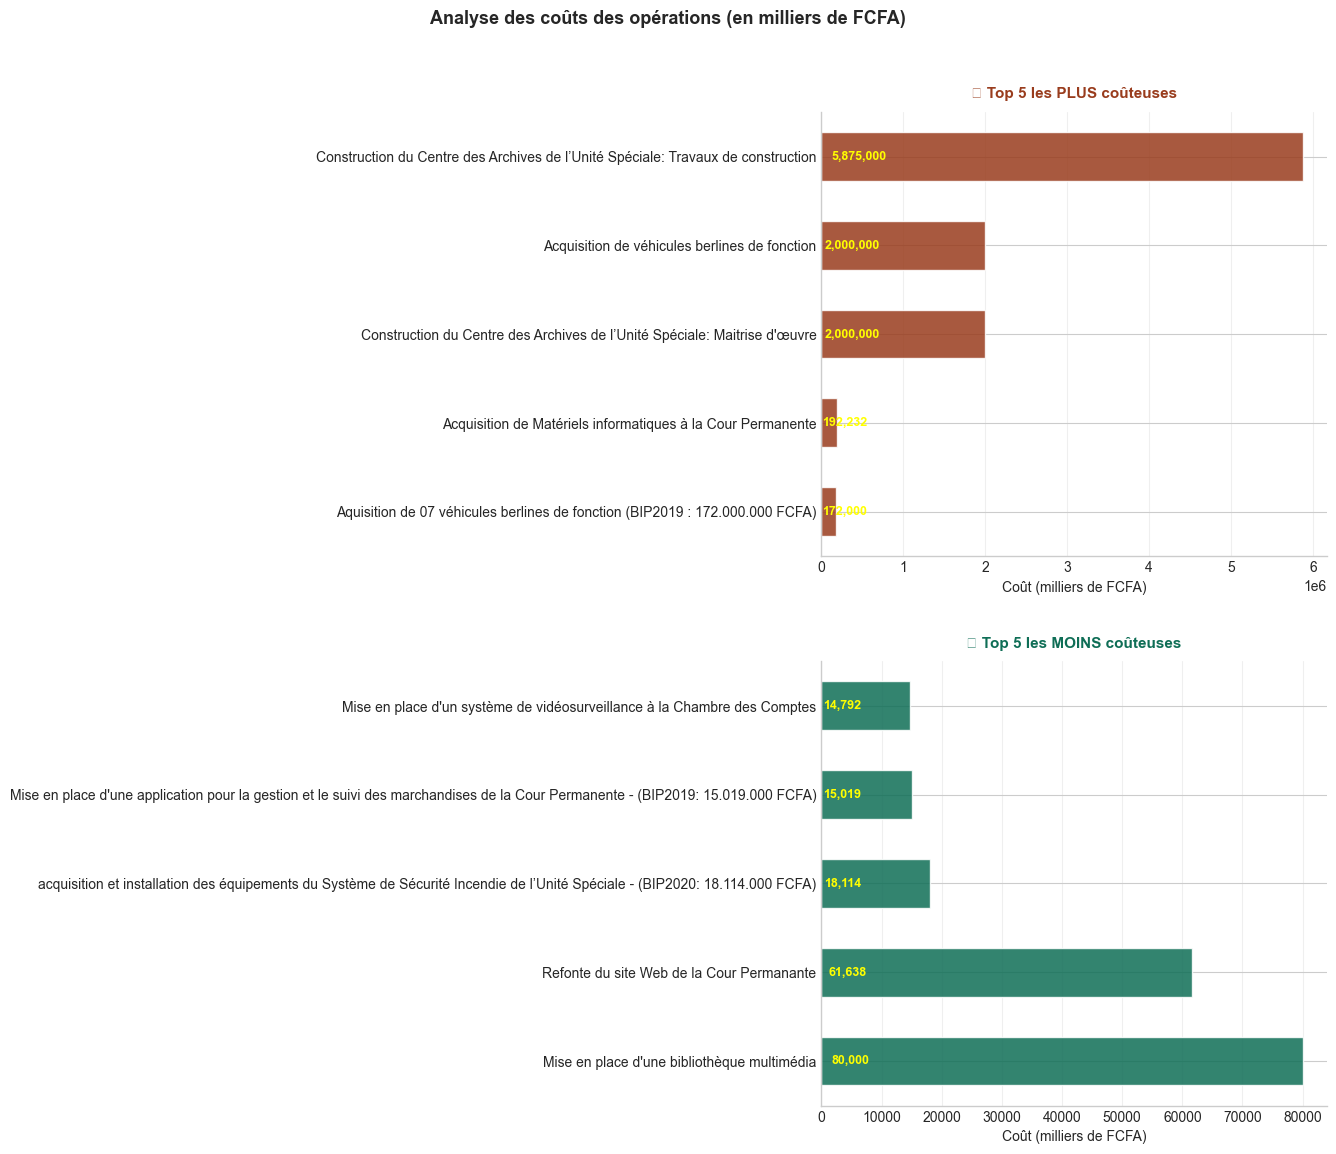

✅ Graphique sauvegardé : 04_top5_couts.png


In [51]:
df_ops_c   = df_operations.dropna(subset=["COUT_NUM"])
df_ops_c   = df_ops_c[df_ops_c["COUT_NUM"] > 0].copy()
top5_plus  = df_ops_c.nlargest(5,  "COUT_NUM").reset_index(drop=True)
top5_moins = df_ops_c.nsmallest(5, "COUT_NUM").reset_index(drop=True)

def afficher_top(df, titre):
    print("=" * 70)
    print(titre)
    print("=" * 70)
    for i, r in df.iterrows():
        print(f"  {i+1}. [{r['ID_OPERATION']}]")
        print(f"     {r['INTITULE_OPERATION'][:65]}")
        print(f"     Coût : {r['COUT_NUM']:>12,.0f} KFCFA"
              f"  |  Exécution : {r['ETAT_EXECUTION']}")
        print()

afficher_top(top5_plus,  "TOP 5 — OPÉRATIONS LES PLUS COÛTEUSES (KFCFA)")
afficher_top(top5_moins, "TOP 5 — OPÉRATIONS LES MOINS COÛTEUSES (KFCFA)")

# ── Visualisation : un graphique AU-DESSUS de l'autre ────────────────────────
# figsize : largeur=14, hauteur=12 (6 par graphique)
# On ne raccourcit plus les intitulés pour les afficher en entier
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Analyse des coûts des opérations (en milliers de FCFA)",
             fontsize=13, fontweight="bold")

for ax, df_top, couleur, titre in [
    (axes[0], top5_plus,  PALETTE[4], "🔴 Top 5 les PLUS coûteuses"),
    (axes[1], top5_moins, PALETTE[1], "🟢 Top 5 les MOINS coûteuses"),
]:
    # Intitulés complets, sans raccourcissement
    labels_b = df_top["INTITULE_OPERATION"].tolist()
    valeurs  = df_top["COUT_NUM"].tolist()

    barres = ax.barh(labels_b, valeurs, color=couleur,
                     alpha=0.85, edgecolor="white", height=0.55)
    ax.invert_yaxis()
    ax.set_title(titre, fontsize=11, fontweight="bold", color=couleur, pad=10)
    ax.set_xlabel("Coût (milliers de FCFA)")
    ax.grid(True, alpha=0.3, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Valeur annotée à l'intérieur de chaque barre
    for b, v in zip(barres, valeurs):
        ax.text(b.get_width() * 0.02,
                b.get_y() + b.get_height() / 2,
                f"{v:,.0f}",
                va="center", fontsize=9,
                fontweight="bold", color="yellow")

# Espace entre les deux graphiques
plt.tight_layout(pad=3.0)
plt.savefig("04_top5_couts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 04_top5_couts.png")

# ==============================================================================
# CELLULE 15 — HISTOGRAMMES : ÉTAT DE MATURITÉ & ÉTAT DE FINANCEMENT
# ==============================================================================


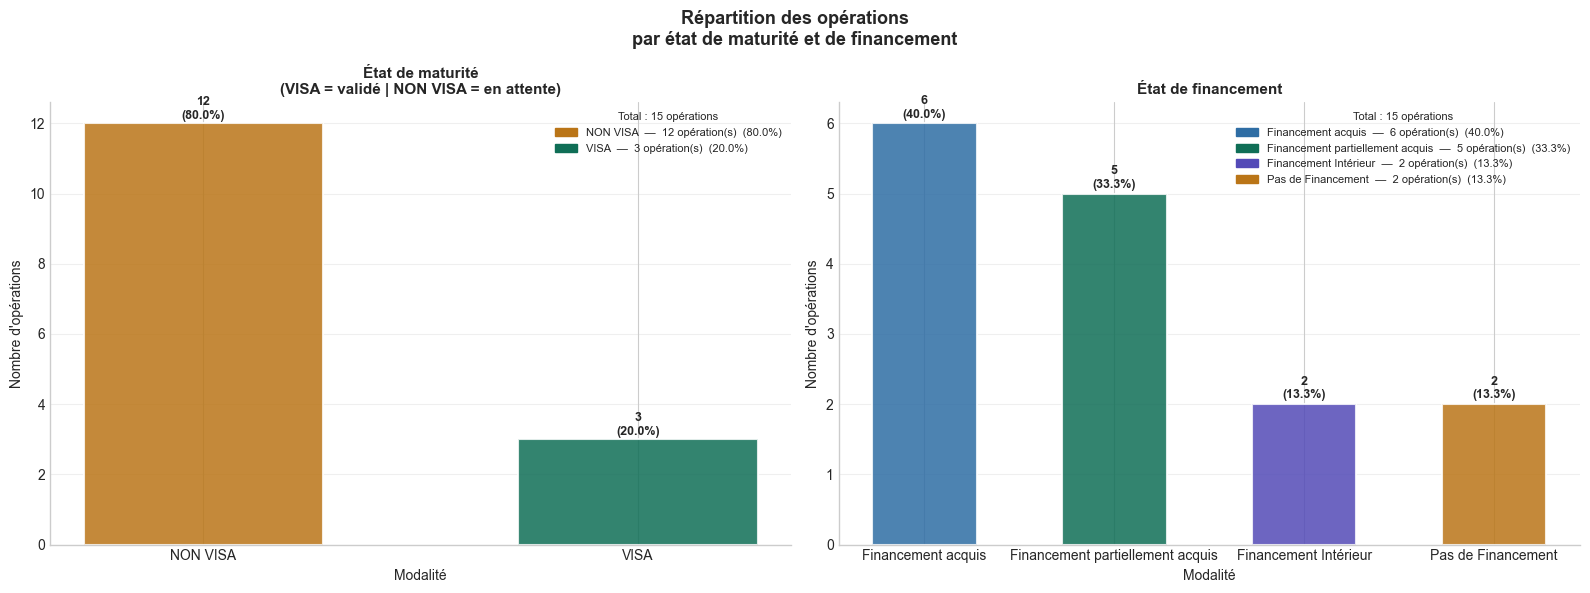

✅ Graphique sauvegardé : 05_histogrammes_etat.png


In [52]:
def histogramme_categorie(ax, serie: pd.Series,
                           titre: str, couleurs_map: dict = None):

    # ── AJOUT ICI ─────────────────────────────────────────────────────────────
    # On remplace les cellules vides/NaN par "Non renseigné"
    # UNIQUEMENT s'il en existe au moins une dans la série.
    # Si toutes les cellules sont renseignées, la série reste inchangée.
    serie = serie.copy()
    if serie.isna().any() or (serie.str.strip() == "").any():
        serie = serie.fillna("Non renseigné")
        serie = serie.where(serie.str.strip() != "", "Non renseigné")
    # ── FIN AJOUT ─────────────────────────────────────────────────────────────

    comptage = serie.str.strip().value_counts().sort_values(ascending=False)
    total    = comptage.sum()
    labs     = comptage.index.tolist()
    vals     = comptage.values.tolist()

    coul = ([couleurs_map.get(l, PALETTE[i % len(PALETTE)])
             for i, l in enumerate(labs)]
            if couleurs_map else
            [PALETTE[i % len(PALETTE)] for i in range(len(labs))])

    # On force la couleur grise pour "Non renseigné" si elle apparaît
    if couleurs_map and "Non renseigné" in labs:
        couleurs_map["Non renseigné"] = PALETTE[7]   # gris
        coul = [couleurs_map.get(l, PALETTE[i % len(PALETTE)])
                for i, l in enumerate(labs)]

    barres = ax.bar(labs, vals, color=coul,
                    alpha=0.85, edgecolor="white",
                    linewidth=1.5, width=0.55)

    for b, v in zip(barres, vals):
        pct = v / total * 100
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + 0.04,
                f"{v}\n({pct:.1f}%)",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.set_ylabel("Nombre d'opérations")
    ax.set_xlabel("Modalité")
    ax.grid(True, alpha=0.3, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    patches = [mpatches.Patch(color=coul[i],
                               label=f"{labs[i]}  —  {vals[i]} opération(s)"
                                     f"  ({vals[i]/total*100:.1f}%)")
               for i in range(len(labs))]
    ax.legend(handles=patches, fontsize=8, framealpha=0.85,
              title=f"Total : {total} opérations", title_fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Répartition des opérations\npar état de maturité et de financement",
             fontsize=13, fontweight="bold")

histogramme_categorie(
    axes[0],
    df_operations["ETAT_MATURITE"].str.strip().str.upper(),
    "État de maturité\n(VISA = validé | NON VISA = en attente)",
    couleurs_map={"VISA": PALETTE[1], "NON VISA": PALETTE[3]}
)

histogramme_categorie(
    axes[1],
    df_operations["ETAT_FINANCEMENT"].str.strip(),
    "État de financement",
    couleurs_map=None
)

plt.tight_layout()
plt.savefig("05_histogrammes_etat.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 05_histogrammes_etat.png")

# ==============================================================================
# CELLULE 16 — DIAGRAMME CIRCULAIRE : ÉTAT D'EXÉCUTION
# ==============================================================================


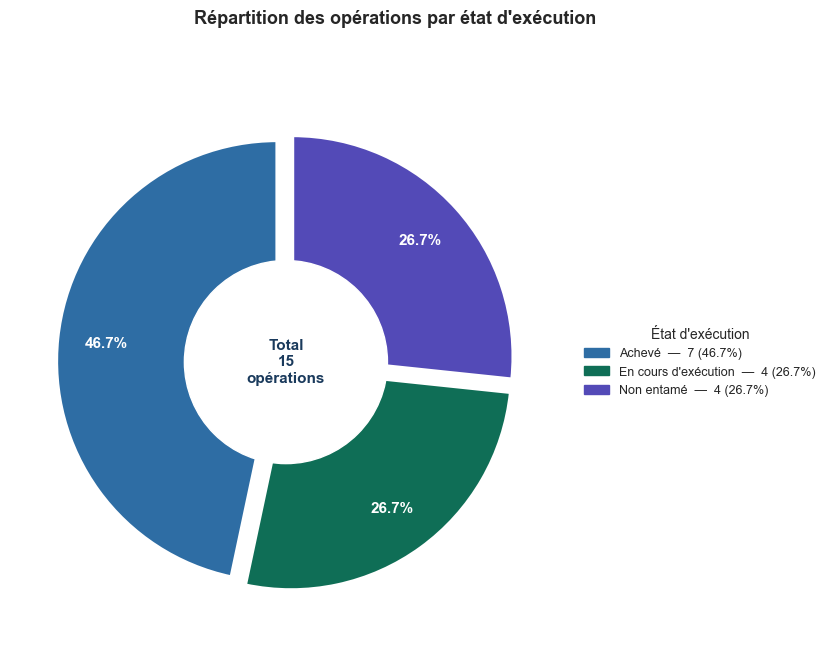

✅ Graphique sauvegardé : 06_etat_execution.png


In [53]:
# ── Gestion des cellules vides ────────────────────────────────────────────────
serie_exec = df_operations["ETAT_EXECUTION"].str.strip().copy()
if serie_exec.isna().any() or (serie_exec == "").any():
    serie_exec = serie_exec.fillna("Non renseigné")
    serie_exec = serie_exec.where(serie_exec != "", "Non renseigné")

comptage_exec = serie_exec.value_counts()
labs_exec     = comptage_exec.index.tolist()
vals_exec     = comptage_exec.values.tolist()
total_exec    = sum(vals_exec)
coul_exec     = [PALETTE[i % len(PALETTE)] for i in range(len(labs_exec))]

fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("Répartition des opérations par état d'exécution",
             fontsize=13, fontweight="bold")

wedges, _, autotexts = ax.pie(
    vals_exec,
    colors      = coul_exec,
    autopct     = "%1.1f%%",
    startangle  = 90,
    pctdistance = 0.78,
    explode     = [0.04] * len(labs_exec),
    wedgeprops  = {"edgecolor": "white", "linewidth": 2.5}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

# Cercle central → effet donut
ax.add_patch(plt.Circle((0, 0), 0.46, color="white"))
ax.text(0, 0, f"Total\n{total_exec}\nopérations",
        ha="center", va="center",
        fontsize=11, fontweight="bold", color=PALETTE[8])

# Légende
patches_exec = [
    mpatches.Patch(color=coul_exec[i],
                   label=f"{labs_exec[i]}  —  "
                         f"{vals_exec[i]} ({vals_exec[i]/total_exec*100:.1f}%)")
    for i in range(len(labs_exec))
]
ax.legend(handles=patches_exec,
          loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=9, framealpha=0.9, title="État d'exécution")

plt.tight_layout()
plt.savefig("06_etat_execution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 06_etat_execution.png")

# ==============================================================================
# CELLULE 17 — KPI : COLONNES BUDGETISÉ ET PROGRAMME
# ==============================================================================

  BUDGÉTISÉ    | Total=15 | OUI=5 (33.3%) | NON=10 (66.7%)
  PROGRAMMÉ    | Total=15 | OUI=0 (0.0%) | NON=15 (100.0%)


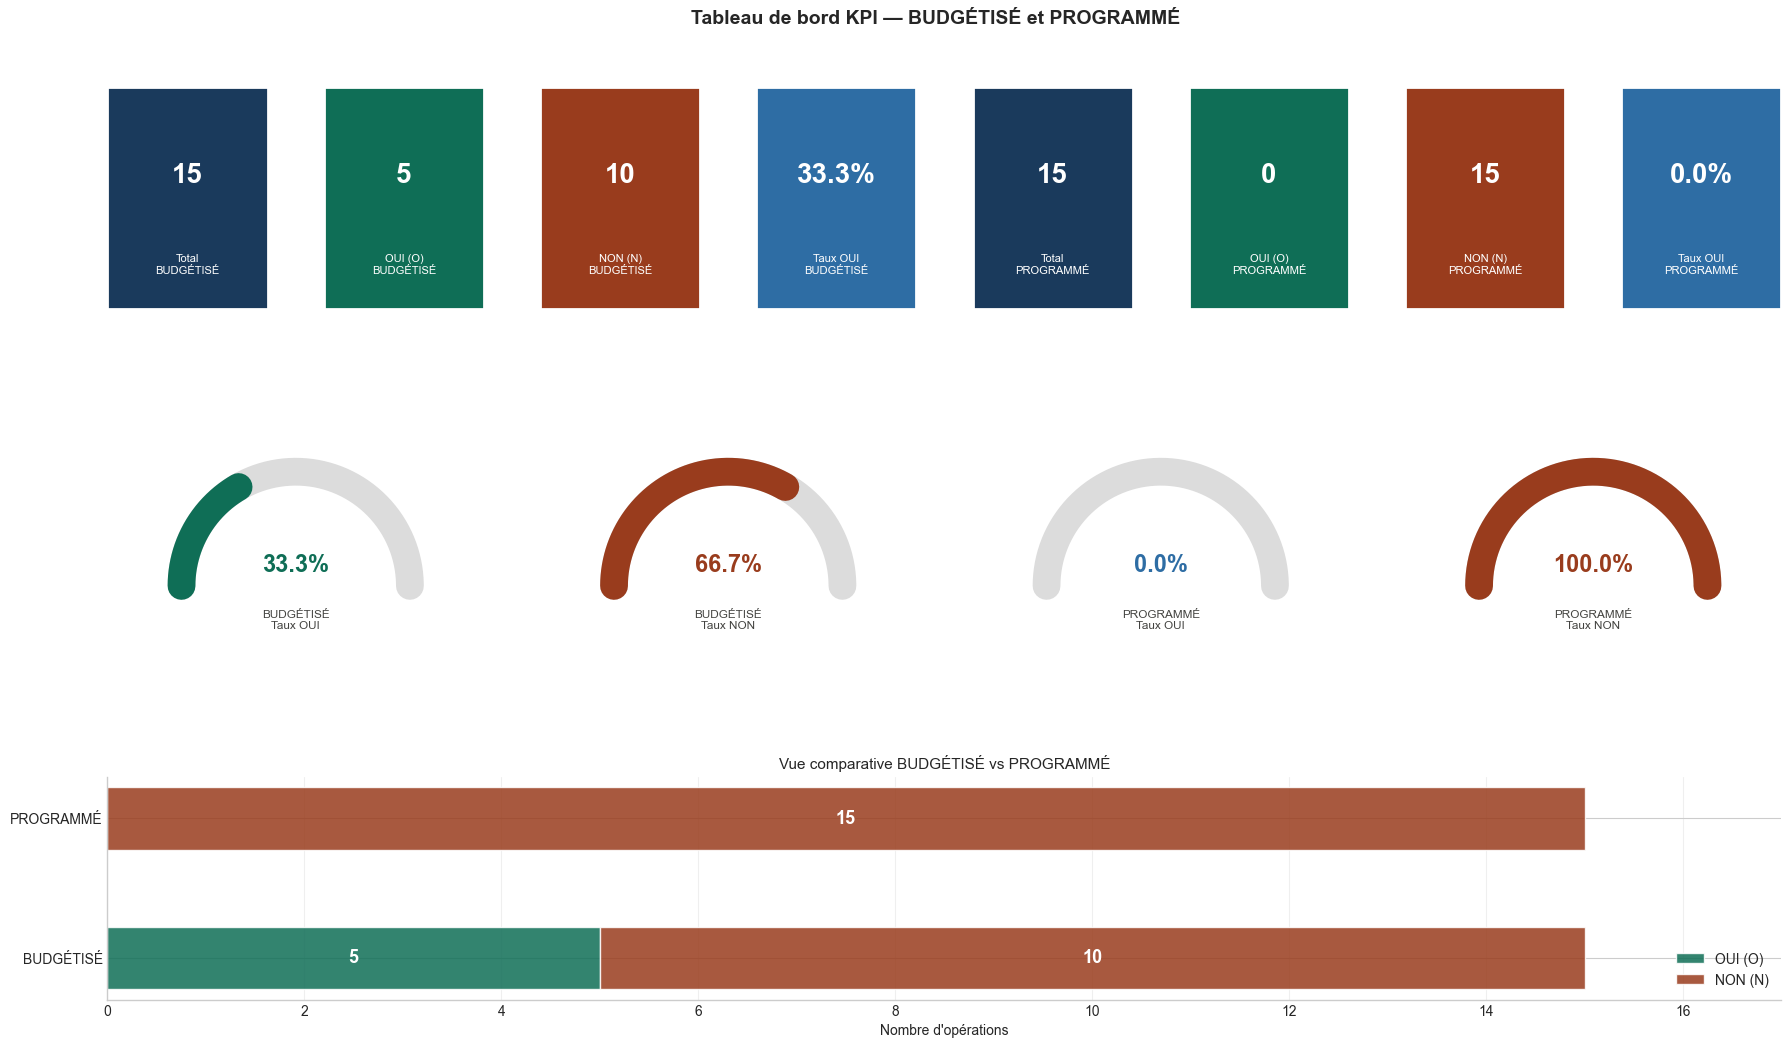

✅ Graphique sauvegardé : 07_kpi.png


In [54]:
# ==============================================================================
# CELLULE 17 — KPI : BUDGETISÉ ET PROGRAMME
# ==============================================================================

def kpi(col: pd.Series, nom: str) -> dict:
    """Calcule les KPIs Oui/Non pour une colonne O/N."""
    s     = col.str.strip().str.upper()
    total = len(s.dropna())
    n_o   = (s == "O").sum()
    n_n   = (s == "N").sum()
    return {"nom"  : nom,   "total": total,
            "n_oui": n_o,   "n_non": n_n,
            "p_oui": n_o / total * 100 if total else 0,
            "p_non": n_n / total * 100 if total else 0}

k_b = kpi(df_operations["BUDGETISE"], "BUDGÉTISÉ")
k_p = kpi(df_operations["PROGRAMME"], "PROGRAMMÉ")

# Affichage console
for k in [k_b, k_p]:
    print(f"  {k['nom']:12s} | Total={k['total']}"
          f" | OUI={k['n_oui']} ({k['p_oui']:.1f}%)"
          f" | NON={k['n_non']} ({k['p_non']:.1f}%)")

# ── Construction du tableau de bord avec GridSpec ─────────────────────────────
# GridSpec permet de définir précisément une grille de sous-graphiques
# sans conflit entre les différentes tailles de lignes.
#
# Layout :
#   Ligne 0 (hspace séparateur de titre)
#   Ligne 1 : 8 cartes métriques côte à côte
#   Ligne 2 : 4 jauges semi-circulaires côte à côte
#   Ligne 3 : 1 graphique de barres empilées

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 11))
fig.suptitle("Tableau de bord KPI — BUDGÉTISÉ et PROGRAMMÉ",
             fontsize=14, fontweight="bold")

# Définition de la grille : 3 lignes × 8 colonnes
# hspace = espace vertical entre lignes
# wspace = espace horizontal entre colonnes
gs = GridSpec(
    nrows=3, ncols=8,
    figure=fig,
    hspace=0.55,
    wspace=0.35,
    top=0.91, bottom=0.08,
    left=0.04, right=0.97
)

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 1 — 8 cartes métriques (4 BUDGÉTISÉ + 4 PROGRAMMÉ)
# ─────────────────────────────────────────────────────────────────────────────
meta = [
    ("Total",    "total", PALETTE[8]),
    ("OUI (O)",  "n_oui", PALETTE[1]),
    ("NON (N)",  "n_non", PALETTE[4]),
    ("Taux OUI", "p_oui", PALETTE[0]),
]

for idx, kdata in enumerate([k_b, k_p]):
    for j, (etiq, cle, coul) in enumerate(meta):

        # idx=0 → colonnes 0-3 (BUDGÉTISÉ)
        # idx=1 → colonnes 4-7 (PROGRAMMÉ)
        col_pos = idx * 4 + j
        ax_c    = fig.add_subplot(gs[0, col_pos])

        ax_c.set_facecolor(coul)

        # Valeur affichée
        valeur = (f"{kdata[cle]:.1f}%"
                  if cle == "p_oui" else str(kdata[cle]))

        ax_c.text(0.5, 0.60, valeur,
                  ha="center", va="center",
                  fontsize=20, fontweight="bold", color="white",
                  transform=ax_c.transAxes)

        ax_c.text(0.5, 0.20,
                  f"{etiq}\n{kdata['nom']}",
                  ha="center", va="center",
                  fontsize=8, color="white",
                  transform=ax_c.transAxes)

        ax_c.set_xticks([])
        ax_c.set_yticks([])
        for sp in ax_c.spines.values():
            sp.set_edgecolor("white")
            sp.set_linewidth(2)

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 2 — 4 jauges semi-circulaires sur la même ligne
# Chaque jauge occupe 2 colonnes de la grille pour avoir assez de place.
# ─────────────────────────────────────────────────────────────────────────────
def jauge(ax, pct, titre, couleur):
    """Dessine une jauge semi-circulaire pour un pourcentage."""
    theta_fond = np.linspace(np.pi, 0, 200)
    theta_val  = np.linspace(np.pi, np.pi * (1 - pct / 100), 200)

    # Arc de fond (gris clair)
    ax.plot(np.cos(theta_fond), np.sin(theta_fond),
            color="#dcdcdc", linewidth=20, solid_capstyle="round",
            zorder=1)
    # Arc coloré (valeur réelle)
    ax.plot(np.cos(theta_val), np.sin(theta_val),
            color=couleur, linewidth=20, solid_capstyle="round",
            zorder=2)

    # Pourcentage au centre
    ax.text(0, 0.18, f"{pct:.1f}%",
            ha="center", va="center",
            fontsize=17, fontweight="bold", color=couleur)
    # Titre sous la jauge
    ax.text(0, -0.30, titre,
            ha="center", va="center",
            fontsize=8.5, color="#444441")

    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-0.60, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")


# Définition des 4 jauges avec leurs colonnes GridSpec (2 colonnes chacune)
jauges_config = [
    (gs[1, 0:2], k_b["p_oui"], "BUDGÉTISÉ\nTaux OUI", PALETTE[1]),
    (gs[1, 2:4], k_b["p_non"], "BUDGÉTISÉ\nTaux NON", PALETTE[4]),
    (gs[1, 4:6], k_p["p_oui"], "PROGRAMMÉ\nTaux OUI", PALETTE[0]),
    (gs[1, 6:8], k_p["p_non"], "PROGRAMMÉ\nTaux NON", PALETTE[4]),
]

for spec, pct, titre, coul in jauges_config:
    ax_j = fig.add_subplot(spec)
    jauge(ax_j, pct, titre, coul)

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 3 — Barres empilées (occupe toute la largeur : 8 colonnes)
# ─────────────────────────────────────────────────────────────────────────────
ax_s = fig.add_subplot(gs[2, :])   # : = toutes les colonnes

cats  = ["BUDGÉTISÉ", "PROGRAMMÉ"]
v_oui = [k_b["n_oui"], k_p["n_oui"]]
v_non = [k_b["n_non"], k_p["n_non"]]

b1 = ax_s.barh(cats, v_oui, color=PALETTE[1], alpha=0.85,
               label="OUI (O)", edgecolor="white", height=0.45)
b2 = ax_s.barh(cats, v_non, left=v_oui, color=PALETTE[4], alpha=0.85,
               label="NON (N)", edgecolor="white", height=0.45)

# Annotations sur les barres
for b, v in zip(b1, v_oui):
    if v:
        ax_s.text(v / 2, b.get_y() + b.get_height() / 2,
                  str(v), ha="center", va="center",
                  fontweight="bold", color="white", fontsize=13)

for b, vo, vn in zip(b2, v_oui, v_non):
    if vn:
        ax_s.text(vo + vn / 2, b.get_y() + b.get_height() / 2,
                  str(vn), ha="center", va="center",
                  fontweight="bold", color="white", fontsize=13)

ax_s.set_xlabel("Nombre d'opérations")
ax_s.set_title("Vue comparative BUDGÉTISÉ vs PROGRAMMÉ", fontsize=11)
ax_s.legend(fontsize=10, loc="lower right")
ax_s.grid(True, alpha=0.3, axis="x")
ax_s.set_xlim(0, max(k_b["total"], k_p["total"]) + 2)
ax_s.spines["top"].set_visible(False)
ax_s.spines["right"].set_visible(False)

plt.savefig("07_kpi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 07_kpi.png")

# ==============================================================================
# CELLULE 18 — SYNTHÈSE FINALE ET EXPORT DES DATAFRAMES
# ==============================================================================


In [55]:
# ==============================================================================
# CELLULE 18 — EXPORT ET SYNTHÈSE FINALE
# ==============================================================================

# ── Étape 1 : construction du mapping ID_OPERATION → ID_PROJET ───────────────
# On relit le PDF une dernière fois en lisant les colonnes 0 et 1 ensemble
# pour reconstituer la relation projet-opération.
# C'est nécessaire car les deux extractions précédentes étaient indépendantes.

def construire_mapping_projet_operation(chemin_pdf: str) -> dict:
    """
    Lit le PDF et construit un dictionnaire :
        {ID_OPERATION: ID_PROJET}

    Logique :
    - Quand la colonne 0 contient un identifiant de projet → on mémorise
      le projet courant.
    - Quand la colonne 1 contient un identifiant d'opération → on associe
      cette opération au dernier projet courant vu (propagation vers le bas).
    """
    mapping      = {}
    projet_actuel = None   # Dernier projet vu en remontant les lignes

    with pdfplumber.open(chemin_pdf) as pdf:
        for page in pdf.pages:
            tableaux = page.extract_tables()
            if not tableaux:
                continue

            for tableau in tableaux:
                for ligne in tableau:
                    cellules = [nettoyer_cellule(c) for c in ligne]
                    while len(cellules) < 11:
                        cellules.append("")
                    cellules = cellules[:11]

                    cel0 = cellules[0]
                    cel1 = cellules[1]

                    # Si la cellule 0 matche un projet → on met à jour
                    # le projet courant
                    m_proj = PATTERN_PROJET.match(cel0)
                    if m_proj:
                        projet_actuel = m_proj.group(1).strip()

                    # Si la cellule 1 matche une opération ET qu'on a
                    # un projet courant → on enregistre l'association
                    m_op = PATTERN_OPERATION.match(cel1)
                    if m_op and projet_actuel:
                        id_op = m_op.group(1).strip()
                        mapping[id_op] = projet_actuel

    print(f"✅ Mapping construit : {len(mapping)} associations opération→projet")
    return mapping


# ── Étape 2 : ajout de ID_PROJET dans df_operations ──────────────────────────
mapping_op_proj = construire_mapping_projet_operation(PDF_PATH)

df_operations["ID_PROJET"] = df_operations["ID_OPERATION"].map(mapping_op_proj)

# Vérification : opérations sans projet associé
sans_projet = df_operations["ID_PROJET"].isna().sum()
if sans_projet > 0:
    print(f"⚠ {sans_projet} opération(s) sans projet associé :")
    print(df_operations[df_operations["ID_PROJET"].isna()]
          [["ID_OPERATION", "INTITULE_OPERATION"]])
else:
    print(f"✅ Toutes les opérations ont un projet associé.")

# ── Étape 3 : jointure avec les clusters ─────────────────────────────────────
# On enrichit df_operations avec les informations de clustering
# issues de df_projets (CLUSTER + CONFIANCE)
df_operations_final = df_operations.merge(
    df_projets[["ID_PROJET", "INTITULE_PROJET", "CLUSTER", "CONFIANCE"]],
    on="ID_PROJET",
    how="left"
)

print(f"\n✅ df_operations_final : {df_operations_final.shape[0]} lignes"
      f" × {df_operations_final.shape[1]} colonnes")
print(f"   Colonnes : {df_operations_final.columns.tolist()}")

# ── Étape 4 : export CSV ──────────────────────────────────────────────────────
df_projets.to_csv("df_projets_final.csv",
                  index=False, encoding="utf-8-sig")
df_operations_final.to_csv("df_operations_final.csv",
                           index=False, encoding="utf-8-sig")

print("\n✅ Fichiers exportés :")
print("   • df_projets_final.csv")
print("   • df_operations_final.csv")

# ── Étape 5 : récapitulatif console ──────────────────────────────────────────
print("\n" + "=" * 60)
print("RÉCAPITULATIF FINAL DU PIPELINE")
print("=" * 60)
print(f"  Projets analysés           : {len(df_projets)}")
print(f"  Opérations analysées       : {len(df_operations)}")
print(f"  K optimal retenu           : {K_OPT}")
print(f"  Score Silhouette           : {sil:.4f}")
print(f"  Davies-Bouldin Index       : {db:.4f}")
print(f"  Calinski-Harabasz Score    : {ch:.4f}")
print(f"  Perte MSE finale (pré)     : {hist_pre[-1]:.6f}")
print(f"  Perte totale finale (IDEC) : {hist_total[-1]:.6f}")

cout_total = df_operations["COUT_NUM"].sum()
cout_moyen = df_operations["COUT_NUM"].mean()
print(f"  Coût total opérations      : {cout_total:,.0f} KFCFA")
print(f"  Coût moyen par opération   : {cout_moyen:,.0f} KFCFA")

print("\n  Graphiques générés :")
for f in ["01_methode_coude.png", "02_courbes_perte.png",
          "03_clusters.png",      "04_top5_couts.png",
          "05_histogrammes_etat.png", "06_etat_execution.png",
          "07_kpi.png"]:
    print(f"    • {f}")

# ── Étape 6 : aperçu du résultat final ───────────────────────────────────────
print("\n--- Aperçu df_operations_final ---")
print(df_operations_final[["ID_PROJET", "ID_OPERATION",
                            "INTITULE_OPERATION", "COUT_NUM",
                            "CLUSTER"]].to_string(index=True))

✅ Mapping construit : 15 associations opération→projet
✅ Toutes les opérations ont un projet associé.

✅ df_operations_final : 15 lignes × 16 colonnes
   Colonnes : ['ID_OPERATION', 'INTITULE_OPERATION', 'NATURE_OPERATION', 'COUT', 'ETAT_MATURITE', 'ETAT_EXECUTION', 'LOCALISATION', 'ETAT_FINANCEMENT', 'SOURCE_FINANCEMENT', 'BUDGETISE', 'PROGRAMME', 'COUT_NUM', 'ID_PROJET', 'INTITULE_PROJET', 'CLUSTER', 'CONFIANCE']

✅ Fichiers exportés :
   • df_projets_final.csv
   • df_operations_final.csv

RÉCAPITULATIF FINAL DU PIPELINE
  Projets analysés           : 12
  Opérations analysées       : 15
  K optimal retenu           : 4
  Score Silhouette           : 0.4483
  Davies-Bouldin Index       : 0.4905
  Calinski-Harabasz Score    : 15.6751
  Perte MSE finale (pré)     : 0.004240
  Perte totale finale (IDEC) : 0.020864
  Coût total opérations      : 10,922,105 KFCFA
  Coût moyen par opération   : 728,140 KFCFA

  Graphiques générés :
    • 01_methode_coude.png
    • 02_courbes_perte.png
   

COÛTS PAR CLUSTER (en milliers de FCFA)
  Cluster 0 | Total=      32,906 | Moyenne=    16,453 | Médiane=    16,453 | Nb opérations=2
  Cluster 1 | Total=   2,364,232 | Moyenne=   788,077 | Médiane=   192,232 | Nb opérations=3
  Cluster 2 | Total=      95,019 | Moyenne=    47,510 | Médiane=    47,510 | Nb opérations=2
  Cluster 3 | Total=   8,429,948 | Moyenne= 1,053,744 | Médiane=    95,764 | Nb opérations=8


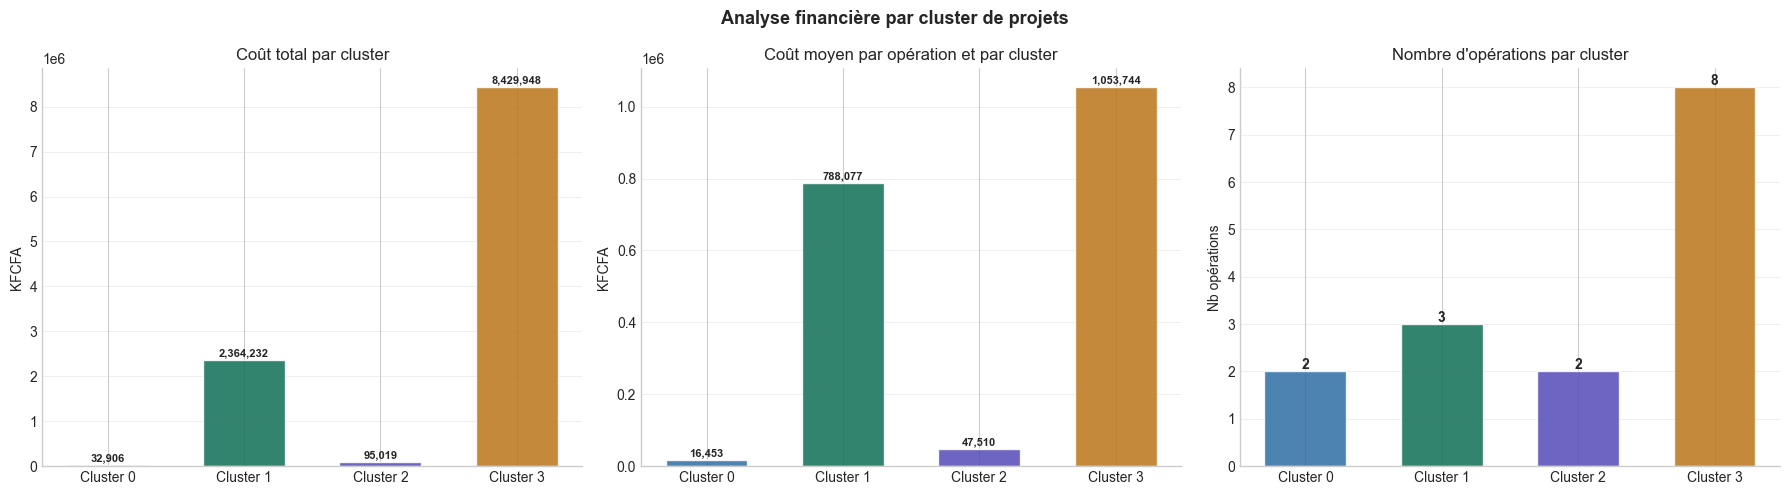

✅ Graphique sauvegardé : 08_couts_par_cluster.png


In [56]:
# ==============================================================================
# ANALYSE 1 — COÛT MOYEN ET TOTAL PAR CLUSTER
# ==============================================================================
# Question : les projets d'un même cluster ont-ils des budgets similaires ?
# On joint df_projets (clusters) avec df_operations (coûts) via le mapping.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Jointure : on associe chaque opération à son cluster via ID_PROJET
df_cluster_cout = df_operations_final.dropna(subset=["COUT_NUM", "CLUSTER"])

# Agrégation par cluster
agg = (df_cluster_cout
       .groupby("CLUSTER")["COUT_NUM"]
       .agg(total="sum", moyenne="mean", nb="count", mediane="median")
       .reset_index())
agg["CLUSTER"] = agg["CLUSTER"].astype(int)

print("=" * 60)
print("COÛTS PAR CLUSTER (en milliers de FCFA)")
print("=" * 60)
for _, r in agg.iterrows():
    print(f"  Cluster {int(r['CLUSTER'])} | "
          f"Total={r['total']:>12,.0f} | "
          f"Moyenne={r['moyenne']:>10,.0f} | "
          f"Médiane={r['mediane']:>10,.0f} | "
          f"Nb opérations={int(r['nb'])}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Analyse financière par cluster de projets",
             fontsize=13, fontweight="bold")

coul = [PALETTE[i % len(PALETTE)] for i in range(len(agg))]
xticks = [f"Cluster {int(c)}" for c in agg["CLUSTER"]]

# Coût total
axes[0].bar(xticks, agg["total"], color=coul, alpha=0.85,
            edgecolor="white", width=0.6)
axes[0].set_title("Coût total par cluster")
axes[0].set_ylabel("KFCFA")
for ax in axes:
    ax.grid(True, alpha=0.3, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
for b, v in zip(axes[0].patches, agg["total"]):
    axes[0].text(b.get_x() + b.get_width()/2,
                 b.get_height() + agg["total"].max()*0.01,
                 f"{v:,.0f}", ha="center", fontsize=8, fontweight="bold")

# Coût moyen
axes[1].bar(xticks, agg["moyenne"], color=coul, alpha=0.85,
            edgecolor="white", width=0.6)
axes[1].set_title("Coût moyen par opération et par cluster")
axes[1].set_ylabel("KFCFA")
for b, v in zip(axes[1].patches, agg["moyenne"]):
    axes[1].text(b.get_x() + b.get_width()/2,
                 b.get_height() + agg["moyenne"].max()*0.01,
                 f"{v:,.0f}", ha="center", fontsize=8, fontweight="bold")

# Nombre d'opérations
axes[2].bar(xticks, agg["nb"], color=coul, alpha=0.85,
            edgecolor="white", width=0.6)
axes[2].set_title("Nombre d'opérations par cluster")
axes[2].set_ylabel("Nb opérations")
for b, v in zip(axes[2].patches, agg["nb"]):
    axes[2].text(b.get_x() + b.get_width()/2,
                 b.get_height() + 0.05,
                 str(int(v)), ha="center",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("08_couts_par_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 08_couts_par_cluster.png")

Table de contingence (effectifs) :
ETAT_EXECUTION  Achevé  En cours d'exécution  Non entamé  TOTAL
ETAT_MATURITE                                                  
NON VISA             7                     2           3     12
VISA                 0                     2           1      3
TOTAL                7                     4           4     15

Table de contingence (% par modalité de maturité) :
ETAT_EXECUTION  Achevé  En cours d'exécution  Non entamé
ETAT_MATURITE                                           
NON VISA          58.3                  16.7        25.0
VISA               0.0                  66.7        33.3


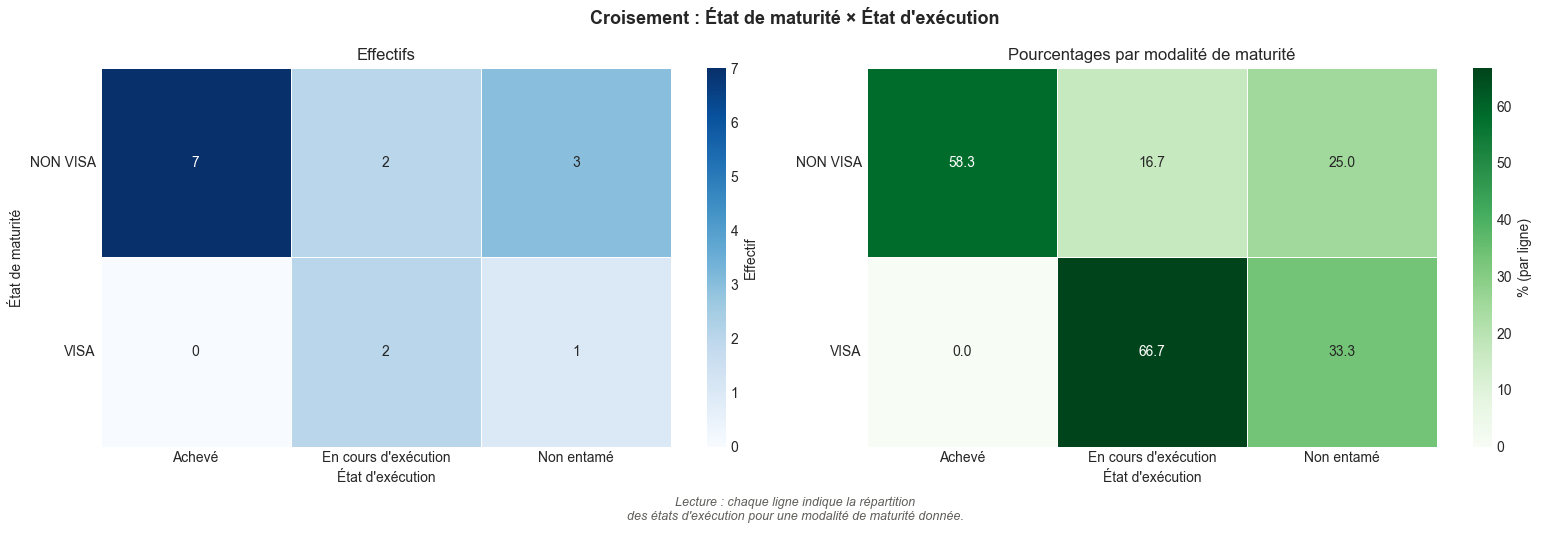

✅ Graphique sauvegardé : 09_croisement_maturite_execution.png


In [57]:
# ==============================================================================
# ANALYSE 2 — MATRICE DE CROISEMENT : ÉTAT DE MATURITÉ × ÉTAT D'EXÉCUTION
# ==============================================================================
# Question : les opérations VISA sont-elles mieux exécutées que les NON VISA ?
# Une heatmap de contingence répond directement à cette question.

df_croise = df_operations.copy()
df_croise["ETAT_MATURITE"]  = df_croise["ETAT_MATURITE"].str.strip().str.upper()
df_croise["ETAT_EXECUTION"] = df_croise["ETAT_EXECUTION"].str.strip()

# Table de contingence : lignes = maturité, colonnes = exécution
contingence = pd.crosstab(
    df_croise["ETAT_MATURITE"],
    df_croise["ETAT_EXECUTION"],
    margins=True,
    margins_name="TOTAL"
)

# Table en pourcentages (sur le total général, hors marges)
contingence_pct = pd.crosstab(
    df_croise["ETAT_MATURITE"],
    df_croise["ETAT_EXECUTION"],
    normalize="index"    # % par ligne = par modalité de maturité
) * 100

print("Table de contingence (effectifs) :")
print(contingence)
print("\nTable de contingence (% par modalité de maturité) :")
print(contingence_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Croisement : État de maturité × État d'exécution",
             fontsize=13, fontweight="bold")

# Heatmap des effectifs
import seaborn as sns
sns.heatmap(
    contingence.drop(index="TOTAL", columns="TOTAL", errors="ignore"),
    annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Effectif"},
    ax=axes[0]
)
axes[0].set_title("Effectifs")
axes[0].set_xlabel("État d'exécution")
axes[0].set_ylabel("État de maturité")
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Heatmap des pourcentages
sns.heatmap(
    contingence_pct,
    annot=True, fmt=".1f", cmap="Greens",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "% (par ligne)"},
    ax=axes[1]
)
axes[1].set_title("Pourcentages par modalité de maturité")
axes[1].set_xlabel("État d'exécution")
axes[1].set_ylabel("")
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

# Annotation d'interprétation
interpretation = (
    "Lecture : chaque ligne indique la répartition\n"
    "des états d'exécution pour une modalité de maturité donnée."
)
fig.text(0.5, -0.04, interpretation,
         ha="center", fontsize=9, color="#5f5e5a",
         style="italic")

plt.tight_layout()
plt.savefig("09_croisement_maturite_execution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 09_croisement_maturite_execution.png")

ANALYSE DU GAP DE FINANCEMENT (en milliers de FCFA)
  ⚠ Partiellement financé             |    7,969,544 KFCFA (73.0%) | 5 opération(s)
  ✅ Financé                           |    2,475,115 KFCFA (22.7%) | 6 opération(s)
  🔴 Non financé                       |      290,427 KFCFA (2.7%) | 2 opération(s)
  ✅ Financé (intérieur)               |      187,019 KFCFA (1.7%) | 2 opération(s)

  TOTAL PORTEFEUILLE :   10,922,105 KFCFA
  GAP TOTAL (non financé)     :      290,427 KFCFA (2.7%)
  GAP PARTIEL (partiellement) :    7,969,544 KFCFA (73.0%)
  EXPOSITION TOTALE AU RISQUE :    8,259,971 KFCFA (75.6%)


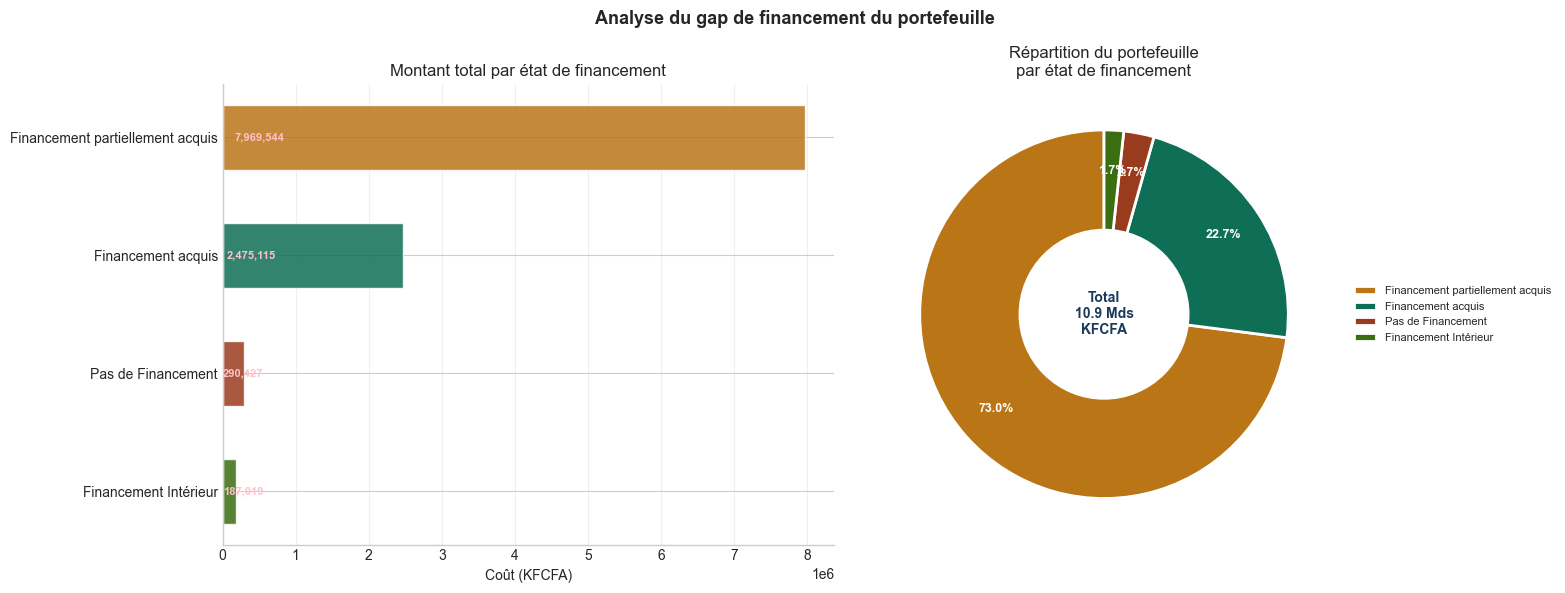

✅ Graphique sauvegardé : 10_gap_financement.png


In [58]:
# ==============================================================================
# ANALYSE 3 — ANALYSE DU GAP DE FINANCEMENT
# ==============================================================================
# Question : quel est le montant total non encore financé ?
# On décompose le portefeuille selon l'état de financement et on calcule
# la part manquante en valeur absolue et en pourcentage.
df_fin = df_operations.dropna(subset=["COUT_NUM"]).copy()
df_fin["ETAT_FINANCEMENT"] = df_fin["ETAT_FINANCEMENT"].str.strip()

agg_fin = (df_fin
           .groupby("ETAT_FINANCEMENT")["COUT_NUM"]
           .agg(total="sum", nb="count")
           .reset_index()
           .sort_values("total", ascending=False))

total_global   = agg_fin["total"].sum()
agg_fin["pct"] = agg_fin["total"] / total_global * 100

def niveau_risque(modalite: str) -> str:
    m = modalite.lower()
    if "acquis" in m and "partiellement" not in m:
        return "✅ Financé"
    elif "partiellement" in m:
        return "⚠ Partiellement financé"
    elif "intérieur" in m or "interieur" in m:
        return "✅ Financé (intérieur)"
    else:
        return "🔴 Non financé"

agg_fin["RISQUE"] = agg_fin["ETAT_FINANCEMENT"].apply(niveau_risque)

print("=" * 70)
print("ANALYSE DU GAP DE FINANCEMENT (en milliers de FCFA)")
print("=" * 70)
for _, r in agg_fin.iterrows():
    print(f"  {r['RISQUE']:35s} | "
          f"{r['total']:>12,.0f} KFCFA ({r['pct']:.1f}%) | "
          f"{int(r['nb'])} opération(s)")
print(f"\n  TOTAL PORTEFEUILLE : {total_global:>12,.0f} KFCFA")

gap     = agg_fin[agg_fin["RISQUE"] == "🔴 Non financé"]["total"].sum()
partiel = agg_fin[agg_fin["RISQUE"] == "⚠ Partiellement financé"]["total"].sum()
print(f"  GAP TOTAL (non financé)     : {gap:>12,.0f} KFCFA"
      f" ({gap/total_global*100:.1f}%)")
print(f"  GAP PARTIEL (partiellement) : {partiel:>12,.0f} KFCFA"
      f" ({partiel/total_global*100:.1f}%)")
print(f"  EXPOSITION TOTALE AU RISQUE : "
      f"{(gap+partiel):>12,.0f} KFCFA"
      f" ({(gap+partiel)/total_global*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analyse du gap de financement du portefeuille",
             fontsize=13, fontweight="bold")

couleurs_risque = {
    "✅ Financé"              : PALETTE[1],
    "✅ Financé (intérieur)"  : PALETTE[5],
    "⚠ Partiellement financé": PALETTE[3],
    "🔴 Non financé"          : PALETTE[4],
}
coul_b = [couleurs_risque.get(r, PALETTE[8]) for r in agg_fin["RISQUE"]]

# ── Barres horizontales — nombre UNIQUEMENT ───────────────────────────────────
barres = axes[0].barh(
    agg_fin["ETAT_FINANCEMENT"],
    agg_fin["total"],
    color=coul_b, alpha=0.85,
    edgecolor="white", height=0.55
)
axes[0].set_title("Montant total par état de financement")
axes[0].set_xlabel("Coût (KFCFA)")
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis="x")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

for b, v in zip(barres, agg_fin["total"]):   # ← p supprimé ici aussi
    axes[0].text(b.get_width() * 0.02,
                 b.get_y() + b.get_height() / 2,
                 f"{v:,.0f}",                # ← nombre uniquement
                 va="center", fontsize=8,
                 fontweight="bold", color="pink")

# ── Donut — pourcentage UNIQUEMENT (autopct le fait déjà) ────────────────────
labels_d = agg_fin["ETAT_FINANCEMENT"].tolist()
vals_d   = agg_fin["total"].tolist()

wedges, _, autotexts = axes[1].pie(
    vals_d, colors=coul_b,
    autopct="%1.1f%%", startangle=90,
    pctdistance=0.78,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
    at.set_color("white")

axes[1].add_patch(plt.Circle((0, 0), 0.46, color="white"))
axes[1].text(0, 0,
             f"Total\n{total_global/1e6:.1f} Mds\nKFCFA",
             ha="center", va="center",
             fontsize=10, fontweight="bold", color=PALETTE[8])
axes[1].set_title("Répartition du portefeuille\npar état de financement")
axes[1].legend(labels_d, loc="center left",
               bbox_to_anchor=(1.02, 0.5),
               fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("10_gap_financement.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 10_gap_financement.png")

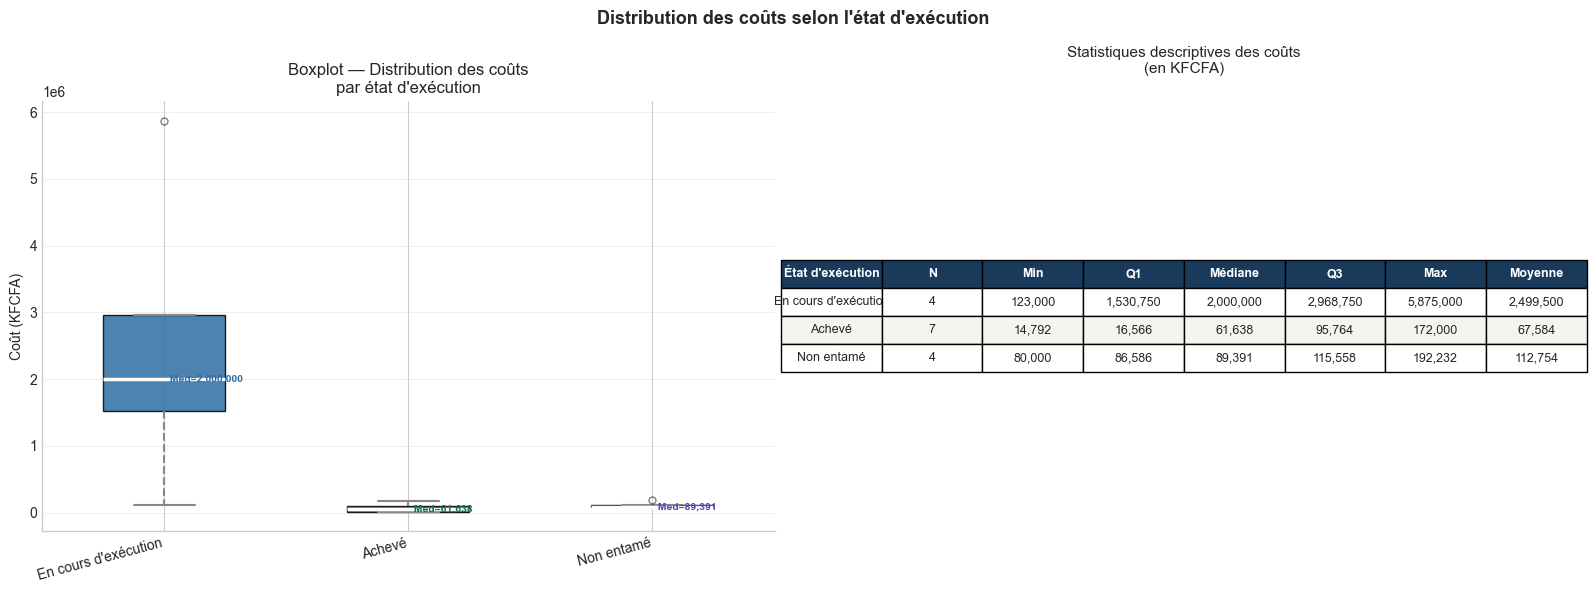

✅ Graphique sauvegardé : 11_boxplot_couts.png


In [59]:
# ==============================================================================
# ANALYSE 4 — BOXPLOT DES COÛTS PAR ÉTAT D'EXÉCUTION
# ==============================================================================
# Question : les opérations achevées coûtent-elles plus ou moins que
# celles en cours ou non entamées ?
# Le boxplot révèle la distribution réelle (médiane, quartiles, extrêmes).

df_box = df_operations.dropna(subset=["COUT_NUM"]).copy()
df_box["ETAT_EXECUTION"] = df_box["ETAT_EXECUTION"].str.strip()

etats_exec = df_box["ETAT_EXECUTION"].unique().tolist()
coul_box   = [PALETTE[i % len(PALETTE)] for i in range(len(etats_exec))]

# Données groupées
groupes = [df_box.loc[df_box["ETAT_EXECUTION"] == e, "COUT_NUM"].dropna().tolist()
           for e in etats_exec]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribution des coûts selon l'état d'exécution",
             fontsize=13, fontweight="bold")

# ── Boxplot ───────────────────────────────────────────────────────────────────
bp = axes[0].boxplot(
    groupes,
    patch_artist=True,
    notch=False,
    vert=True,
    widths=0.5,
    medianprops={"color": "white", "linewidth": 2.5}
)
for patch, c in zip(bp["boxes"], coul_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
for whisker in bp["whiskers"]:
    whisker.set(color="#888780", linewidth=1.5, linestyle="--")
for cap in bp["caps"]:
    cap.set(color="#888780", linewidth=1.5)
for flier in bp["fliers"]:
    flier.set(marker="o", color="#888780", alpha=0.5, markersize=5)

axes[0].set_xticks(range(1, len(etats_exec)+1))
axes[0].set_xticklabels(etats_exec, rotation=15, ha="right")
axes[0].set_ylabel("Coût (KFCFA)")
axes[0].set_title("Boxplot — Distribution des coûts\npar état d'exécution")
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Annotation des médianes
for i, (grp, c) in enumerate(zip(groupes, coul_box)):
    if grp:
        med = np.median(grp)
        axes[0].text(i + 1, med,
                     f"  Med={med:,.0f}",
                     va="center", fontsize=7.5,
                     color=c, fontweight="bold")

# ── Statistiques descriptives sous forme de tableau ──────────────────────────
stats_rows = []
for e, grp in zip(etats_exec, groupes):
    if grp:
        stats_rows.append({
            "État d'exécution": e,
            "N"       : len(grp),
            "Min"     : f"{min(grp):,.0f}",
            "Q1"      : f"{np.percentile(grp,25):,.0f}",
            "Médiane" : f"{np.median(grp):,.0f}",
            "Q3"      : f"{np.percentile(grp,75):,.0f}",
            "Max"     : f"{max(grp):,.0f}",
            "Moyenne" : f"{np.mean(grp):,.0f}",
        })
df_stats = pd.DataFrame(stats_rows)

axes[1].axis("off")
table = axes[1].table(
    cellText=df_stats.values,
    colLabels=df_stats.columns,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.8)

# Couleur de l'en-tête
for j in range(len(df_stats.columns)):
    table[(0, j)].set_facecolor(PALETTE[8])
    table[(0, j)].set_text_props(color="white", fontweight="bold")

# Couleur des lignes alternées
for i in range(1, len(df_stats) + 1):
    bg = "#f5f5f0" if i % 2 == 0 else "white"
    for j in range(len(df_stats.columns)):
        table[(i, j)].set_facecolor(bg)

axes[1].set_title("Statistiques descriptives des coûts\n(en KFCFA)",
                  fontsize=11, pad=20)

plt.tight_layout()
plt.savefig("11_boxplot_couts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 11_boxplot_couts.png")

Profils moyens par cluster (0=mauvais, 1=excellent) :
 CLUSTER  MATURITE_SCORE  EXECUTION_SCORE  FIN_SCORE  BUDG_SCORE  PROG_SCORE
       0        0.000000           1.0000   0.500000    0.500000         0.0
       1        0.333333           0.5000   0.333333    0.666667         0.0
       2        0.000000           0.5000   0.750000    0.500000         0.0
       3        0.250000           0.5625   0.750000    0.125000         0.0


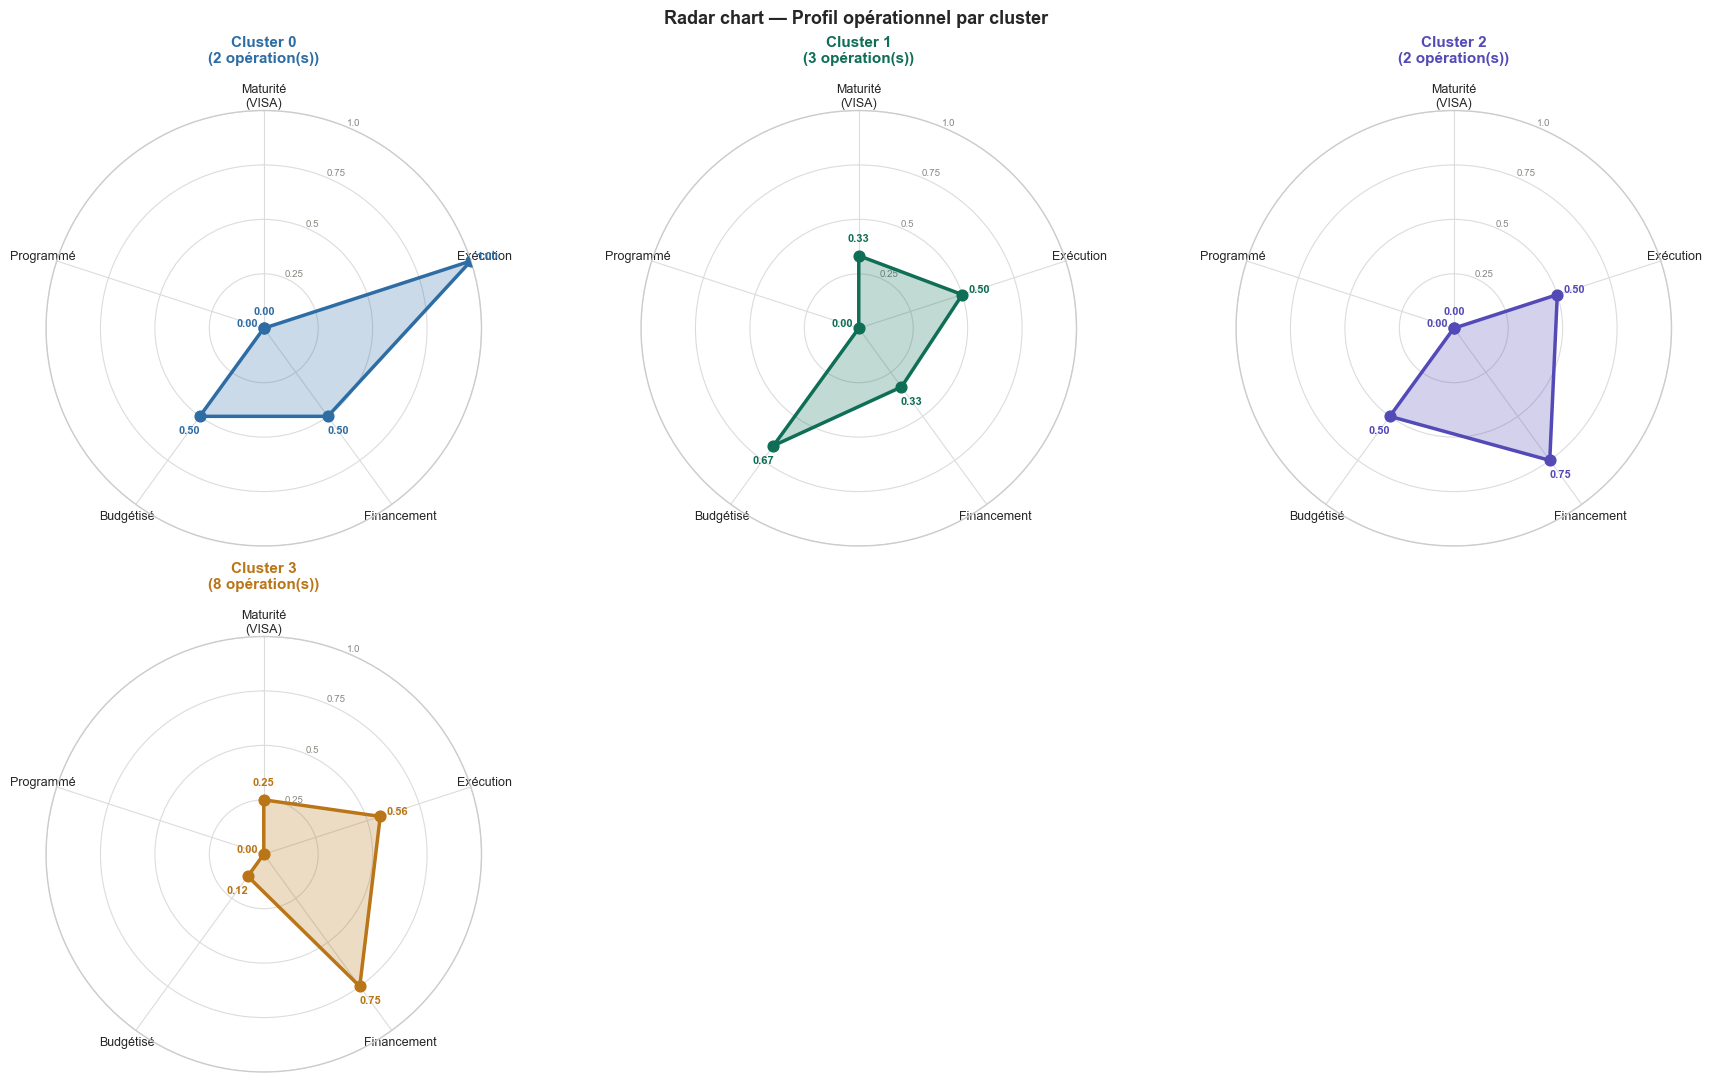

✅ Graphique sauvegardé : 12_radar_clusters.png


In [60]:
# ==============================================================================
# ANALYSE 5 — RADAR CHART PAR CLUSTER
# ==============================================================================
# Question : chaque cluster a-t-il un profil financier et opérationnel distinct ?
# Le radar chart permet de visualiser 5 dimensions simultanément par cluster.

from matplotlib.patches import FancyArrowPatch

df_radar = df_operations_final.dropna(subset=["CLUSTER"]).copy()
df_radar["CLUSTER"] = df_radar["CLUSTER"].astype(int)

# Encodage numérique des colonnes catégorielles pour le radar
df_radar["MATURITE_SCORE"] = (
    df_radar["ETAT_MATURITE"].str.strip().str.upper()
    .map({"VISA": 1, "NON VISA": 0}).fillna(0)
)
df_radar["EXECUTION_SCORE"] = (
    df_radar["ETAT_EXECUTION"].str.strip()
    .map({"Achevé": 1.0, "En cours d'exécution": 0.5, "Non entamé": 0.0})
    .fillna(0)
)
df_radar["FIN_SCORE"] = (
    df_radar["ETAT_FINANCEMENT"].str.strip()
    .apply(lambda x: (
        1.0 if "acquis" in x.lower() and "partiel" not in x.lower()
        else 0.5 if "partiel" in x.lower() or "intérieur" in x.lower()
        else 0.0
    ))
)
df_radar["BUDG_SCORE"] = (
    df_radar["BUDGETISE"].str.strip().str.upper()
    .map({"O": 1, "N": 0}).fillna(0)
)
df_radar["PROG_SCORE"] = (
    df_radar["PROGRAMME"].str.strip().str.upper()
    .map({"O": 1, "N": 0}).fillna(0)
)

# Agrégation par cluster
dimensions = ["MATURITE_SCORE", "EXECUTION_SCORE",
              "FIN_SCORE", "BUDG_SCORE", "PROG_SCORE"]
labels_radar = ["Maturité\n(VISA)", "Exécution",
                "Financement", "Budgétisé", "Programmé"]

profils = (df_radar.groupby("CLUSTER")[dimensions]
           .mean().reset_index())
profils["CLUSTER"] = profils["CLUSTER"].astype(int)

print("Profils moyens par cluster (0=mauvais, 1=excellent) :")
print(profils.to_string(index=False))

# ── Tracé du radar chart ──────────────────────────────────────────────────────
N      = len(dimensions)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # Fermeture du polygone

nb_clusters = len(profils)
cols_r = min(nb_clusters, 3)
rows_r = -(-nb_clusters // cols_r)

fig, axes = plt.subplots(rows_r, cols_r,
                          figsize=(6 * cols_r, 5.5 * rows_r),
                          subplot_kw={"projection": "polar"})
fig.suptitle("Radar chart — Profil opérationnel par cluster",
             fontsize=13, fontweight="bold")

# Gestion du cas où axes n'est pas un tableau 2D
if nb_clusters == 1:
    axes = np.array([[axes]])
elif rows_r == 1:
    axes = axes.reshape(1, -1)

for idx, row in profils.iterrows():
    r   = idx // cols_r
    c   = idx % cols_r
    ax  = axes[r, c]
    coul = PALETTE[int(row["CLUSTER"]) % len(PALETTE)]

    vals  = row[dimensions].tolist()
    vals += vals[:1]   # Fermeture

    # Grille de fond
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_radar, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"],
                        fontsize=7, color="#888780")
    ax.grid(color="#dcdcdc", linewidth=0.8)

    # Remplissage du polygone
    ax.fill(angles, vals, color=coul, alpha=0.25)
    ax.plot(angles, vals, color=coul, linewidth=2.5)

    # Points aux sommets
    ax.scatter(angles[:-1], vals[:-1],
               color=coul, s=60, zorder=5)

    # Annotations des valeurs
    for angle, val in zip(angles[:-1], vals[:-1]):
        ax.text(angle, val + 0.08, f"{val:.2f}",
                ha="center", va="center",
                fontsize=8, fontweight="bold", color=coul)

    ax.set_title(f"Cluster {int(row['CLUSTER'])}\n"
                 f"({len(df_radar[df_radar['CLUSTER']==int(row['CLUSTER'])])} opération(s))",
                 fontsize=11, pad=15, color=coul, fontweight="bold")

# Masquage des sous-graphiques vides
for idx in range(nb_clusters, rows_r * cols_r):
    r, c = idx // cols_r, idx % cols_r
    axes[r, c].set_visible(False)

plt.tight_layout()
plt.savefig("12_radar_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 12_radar_clusters.png")

In [61]:
import plotly
print(plotly.__version__)


5.20.0


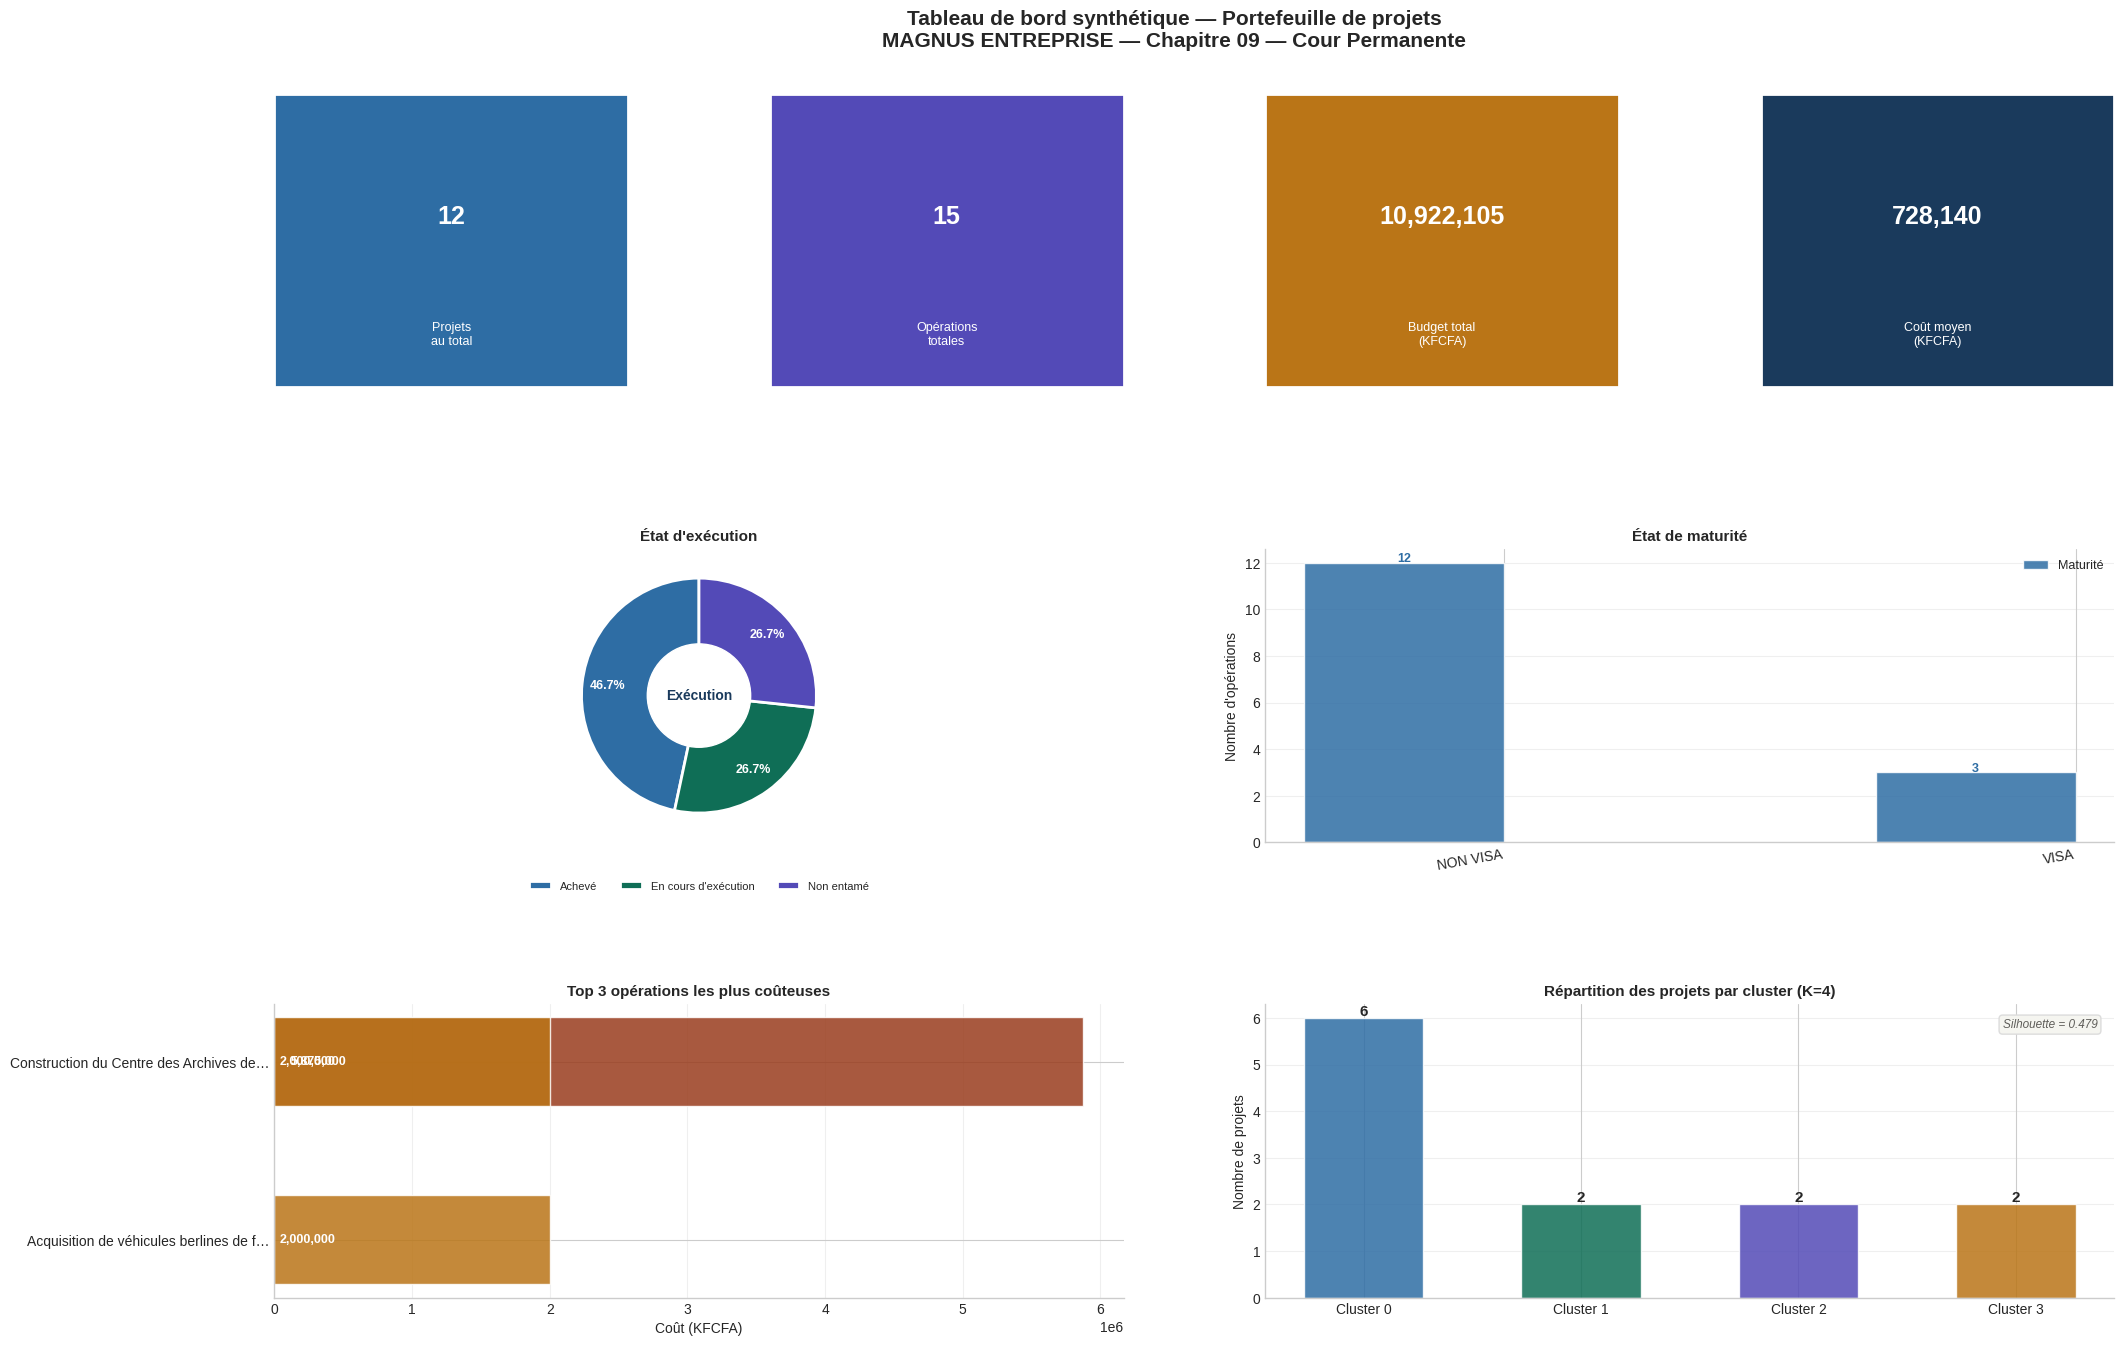

✅ Graphique sauvegardé : 13_tableau_bord_synthese.png


In [28]:
# ==============================================================================
# ANALYSE 6 — TABLEAU DE BORD SYNTHÉTIQUE DU PORTEFEUILLE
# ==============================================================================
# Vue d'ensemble en une seule figure : résumé exécutif pour la direction.
# Combine les indicateurs clés les plus parlants en un tableau de bord unique.

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 14))
fig.suptitle("Tableau de bord synthétique — Portefeuille de projets\n"
             "MAGNUS ENTREPRISE — Chapitre 09 — Cour Permanente",
             fontsize=15, fontweight="bold", y=0.98)

gs = GridSpec(3, 4, figure=fig,
              hspace=0.55, wspace=0.40,
              top=0.92, bottom=0.06,
              left=0.05, right=0.97)

# ── Cartes KPI globales (ligne 0, 4 cartes) ───────────────────────────────────
kpis_globaux = [
    ("Projets\nau total",     len(df_projets),                            PALETTE[0]),
    ("Opérations\ntotales",   len(df_operations),                         PALETTE[2]),
    ("Budget total\n(KFCFA)", f"{df_operations['COUT_NUM'].sum():,.0f}",  PALETTE[3]),
    ("Coût moyen\n(KFCFA)",   f"{df_operations['COUT_NUM'].mean():,.0f}", PALETTE[8]),
]
for j, (titre, valeur, coul) in enumerate(kpis_globaux):
    ax_k = fig.add_subplot(gs[0, j])
    ax_k.set_facecolor(coul)
    ax_k.text(0.5, 0.58, str(valeur),
              ha="center", va="center",
              fontsize=18, fontweight="bold", color="white",
              transform=ax_k.transAxes)
    ax_k.text(0.5, 0.18, titre,
              ha="center", va="center",
              fontsize=9, color="white",
              transform=ax_k.transAxes)
    ax_k.set_xticks([])
    ax_k.set_yticks([])
    for sp in ax_k.spines.values():
        sp.set_edgecolor("white")
        sp.set_linewidth(2)

# ── Ligne 1 gauche : Répartition par état d'exécution (donut) ─────────────────
ax_d = fig.add_subplot(gs[1, 0:2])
exec_c = df_operations["ETAT_EXECUTION"].str.strip().value_counts()
coul_e = [PALETTE[i % len(PALETTE)] for i in range(len(exec_c))]
wedges, _, ats = ax_d.pie(
    exec_c.values, colors=coul_e,
    autopct="%1.1f%%", startangle=90,
    pctdistance=0.78,
    wedgeprops={"edgecolor": "white", "linewidth": 2.0}
)
for at in ats:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")
ax_d.add_patch(plt.Circle((0,0), 0.44, color="white"))
ax_d.text(0, 0, "Exécution",
          ha="center", va="center",
          fontsize=10, fontweight="bold", color=PALETTE[8])
ax_d.legend(
    wedges, exec_c.index.tolist(),
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=len(exec_c),
    fontsize=8, framealpha=0.8
)
ax_d.set_title("État d'exécution", fontsize=11, fontweight="bold")

# ── Ligne 1 droite : Maturité et financement (barres groupées) ────────────────
ax_b = fig.add_subplot(gs[1, 2:4])
mat_c  = df_operations["ETAT_MATURITE"].str.strip().str.upper().value_counts()
fin_c  = df_operations["ETAT_FINANCEMENT"].str.strip().value_counts().head(3)

x      = np.arange(len(mat_c))
width  = 0.35
ax_b.bar(x - width/2, mat_c.values, width, label="Maturité",
         color=PALETTE[0], alpha=0.85, edgecolor="white")
for xi, v in zip(x - width/2, mat_c.values):
    ax_b.text(xi, v + 0.05, str(v),
              ha="center", fontsize=9, fontweight="bold", color=PALETTE[0])

ax_b.set_xticks(x)
ax_b.set_xticklabels(mat_c.index, rotation=10, ha="right")
ax_b.set_ylabel("Nombre d'opérations")
ax_b.set_title("État de maturité", fontsize=11, fontweight="bold")
ax_b.grid(True, alpha=0.3, axis="y")
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)
ax_b.legend(fontsize=9)

# ── Ligne 2 gauche : Top 3 opérations les plus coûteuses ─────────────────────
ax_t = fig.add_subplot(gs[2, 0:2])
top3 = df_operations.dropna(subset=["COUT_NUM"]).nlargest(3, "COUT_NUM")
lbl3 = [r["INTITULE_OPERATION"][:38] + "…"
        if len(r["INTITULE_OPERATION"]) > 38
        else r["INTITULE_OPERATION"]
        for _, r in top3.iterrows()]
barres3 = ax_t.barh(lbl3, top3["COUT_NUM"].values,
                     color=[PALETTE[4], PALETTE[3], PALETTE[3]],
                     alpha=0.85, edgecolor="white", height=0.5)
ax_t.invert_yaxis()
ax_t.set_title("Top 3 opérations les plus coûteuses", fontsize=11, fontweight="bold")
ax_t.set_xlabel("Coût (KFCFA)")
ax_t.grid(True, alpha=0.3, axis="x")
ax_t.spines["top"].set_visible(False)
ax_t.spines["right"].set_visible(False)
for b, v in zip(barres3, top3["COUT_NUM"].values):
    ax_t.text(b.get_width() * 0.02,
              b.get_y() + b.get_height()/2,
              f"{v:,.0f}", va="center",
              fontsize=9, fontweight="bold", color="white")

# ── Ligne 2 droite : Clusters et nombre de projets ───────────────────────────
ax_cl = fig.add_subplot(gs[2, 2:4])
cluster_c = df_projets["CLUSTER"].value_counts().sort_index()
xtk       = [f"Cluster {int(c)}" for c in cluster_c.index]
coul_cl   = [PALETTE[int(c) % len(PALETTE)] for c in cluster_c.index]

bars_cl = ax_cl.bar(xtk, cluster_c.values,
                     color=coul_cl, alpha=0.85,
                     edgecolor="white", width=0.55)
ax_cl.set_title(f"Répartition des projets par cluster (K={K_OPT})",
                fontsize=11, fontweight="bold")
ax_cl.set_ylabel("Nombre de projets")
ax_cl.grid(True, alpha=0.3, axis="y")
ax_cl.spines["top"].set_visible(False)
ax_cl.spines["right"].set_visible(False)
for b, v in zip(bars_cl, cluster_c.values):
    ax_cl.text(b.get_x() + b.get_width()/2,
               b.get_height() + 0.05,
               str(int(v)), ha="center",
               fontsize=11, fontweight="bold")

# Annotation Silhouette score
ax_cl.text(0.98, 0.95,
           f"Silhouette = {sil:.3f}",
           transform=ax_cl.transAxes,
           ha="right", va="top",
           fontsize=8.5, style="italic",
           color="#5f5e5a",
           bbox=dict(boxstyle="round,pad=0.3",
                     facecolor="#f5f5f0",
                     edgecolor="#dcdcdc"))

plt.savefig("13_tableau_bord_synthese.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : 13_tableau_bord_synthese.png")